# Tutorial 9 — Model Comparison

**Statistical Computation and Analysis — Spring 2026**

This tutorial continues the regression models from Tutorial 8 and uses the same dataset, `foodDiet_extended.csv`.

The goal is to learn how to compare candidate models after each model has gone through the Bayesian workflow.

## Main goals

1. Understand why explained-variance summaries such as \(R^2\) are not enough for model comparison.
2. Fit several candidate Bayesian regression models for the same outcome.
3. Store the pointwise log likelihood required for WAIC and LOO.
4. Perform the Bayesian workflow for every candidate model:
   - model definition
   - prior predictive check
   - posterior sampling
   - sampling diagnostics
   - posterior summary
   - posterior predictive check
5. Compare candidate models using:
   - AIC
   - WAIC
   - LOO (PSIS-LOO-CV)
6. Interpret ArviZ comparison tables carefully.
7. Summarize the effect-size measures learned in the previous tutorial.
8. Understand where model comparison belongs in the Bayesian workflow.

## Dataset and outcome

The dependent variable is:

\[
weight\_loss = weight\_before - weight\_after
\]

Positive values mean larger weight loss.

## Candidate models

The tutorial compares increasingly complex candidate models:

| Model | Formula | Main question |
|---|---|---|
| intercept only | `weight_loss ~ 1` | How well can we predict weight loss with no predictors? |
| height only | `weight_loss ~ height_z` | Does height improve prediction? |
| height + age | `weight_loss ~ height_z + age_z` | Does age add predictive information beyond height? |
| height * age | `weight_loss ~ height_z * age_z` | Does the height effect depend on age? |
| height * age + diet | `weight_loss ~ height_z * age_z + diet_type` | Does diet type add predictive information after height, age, and their interaction? |

All Bayesian models use a Gaussian likelihood:

\[
weight\_loss_i \sim Normal(\mu_i, \sigma)
\]

The models differ only in how they define the expected value \(\mu_i\).


## 1. Setup

The package versions match the course compatibility settings used in earlier tutorials.

Run this cell first. If packages are installed or changed, restart the runtime and run the notebook again from the beginning.

In [1]:
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version

IS_COLAB = "google.colab" in sys.modules

COURSE_PACKAGE_VERSIONS = {
    "arviz": "0.22.0",
    "matplotlib": "3.10.0",
    "numpy": "2.0.2",
    "pandas": "2.2.2",
    "pymc": "5.28.4",
    "scipy": "1.16.3",
    "seaborn": "0.13.2",
}

EXTRA_PACKAGES = {
    "bambi": None,
    "statsmodels": None,
    "preliz": None,
    "packaging": None,
    "watermark": None,
}

packages_to_install = []

for package_name, required_version in COURSE_PACKAGE_VERSIONS.items():
    try:
        current_version = version(package_name)
        print(f"{package_name:10s}: {current_version}")
        if Version(current_version) != Version(required_version):
            packages_to_install.append(f"{package_name}=={required_version}")
    except PackageNotFoundError:
        packages_to_install.append(f"{package_name}=={required_version}")

for package_name in EXTRA_PACKAGES:
    try:
        current_version = version(package_name)
        print(f"{package_name:10s}: {current_version}")
    except PackageNotFoundError:
        packages_to_install.append(package_name)

if len(packages_to_install) > 0:
    print("Installing/updating packages:")
    for package in packages_to_install:
        print(" -", package)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages_to_install
    ])

    print("Packages were installed or changed.")
    print("Restart the runtime now, then run all cells again from the beginning.")
    raise SystemExit("Restart the runtime, then run all cells again from the beginning.")
else:
    print("All required course package versions are already installed.")

arviz     : 0.22.0
matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
pymc      : 5.28.4
scipy     : 1.16.3
seaborn   : 0.13.2
bambi     : 0.17.2
statsmodels: 0.14.6
preliz    : 0.24.0
packaging : 26.2
watermark : 2.6.0
All required course package versions are already installed.


In [2]:
from pathlib import Path
import urllib.request
import warnings

import arviz as az
import bambi as bmb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import scipy
import seaborn as sns
import statsmodels
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"arviz      : {az.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"pymc       : {pm.__version__}")
print(f"scipy      : {scipy.__version__}")
print(f"seaborn    : {sns.__version__}")
print(f"bambi      : {bmb.__version__}")
print(f"preliz     : {pz.__version__}")
print(f"statsmodels: {statsmodels.__version__}")

assert az.__version__ == "0.22.0"
assert matplotlib.__version__ == "3.10.0"
assert np.__version__ == "2.0.2"
assert pd.__version__ == "2.2.2"
assert pm.__version__ == "5.28.4"
assert scipy.__version__ == "1.16.3"
assert sns.__version__ == "0.13.2"

RANDOM_SEED = 17
rng = np.random.default_rng(RANDOM_SEED)
HDI_MASS = 0.94

az.style.use("arviz-whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Colab detected:", IS_COLAB)

arviz      : 0.22.0
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
pymc       : 5.28.4
scipy      : 1.16.3
seaborn    : 0.13.2
bambi      : 0.17.2
preliz     : 0.24.0
statsmodels: 0.14.6
Colab detected: True


## 2. Load the dataset

The notebook first searches for a local `foodDiet_extended.csv` file. If no file is found, it downloads the file from the course GitHub repository.

In [3]:
FOOD_DIET_URL = "https://raw.githubusercontent.com/opherdonchin/StatisticsCourse_36714361/main/Data/foodDiet_extended.csv"

SEARCH_FILENAMES = [
    "foodDiet_extended.csv",
    "FoodDiet_extended.csv",
    "food_diet_extended.csv",
    "foodDiet.csv",
]
SEARCH_DIRS = [Path("."), Path("data"), Path("Data"), Path("/content"), Path("/content/data")]


def find_local_food_diet_file():
    for directory in SEARCH_DIRS:
        for filename in SEARCH_FILENAMES:
            candidate = directory / filename
            if candidate.exists():
                return candidate
    return None


food_diet_path = find_local_food_diet_file()

if food_diet_path is None:
    print("No local foodDiet_extended file found. Downloading public CSV...")
    food_diet_path = Path("foodDiet_extended.csv")
    urllib.request.urlretrieve(FOOD_DIET_URL, food_diet_path)
else:
    print(f"Using local file: {food_diet_path}")

food_raw = pd.read_csv(food_diet_path)

print("Dataset shape:", food_raw.shape)
display(food_raw.head())
print("Columns:")
print(food_raw.columns.tolist())

No local foodDiet_extended file found. Downloading public CSV...
Dataset shape: (480, 7)


,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
0,1,0,22,159,58.0,1,54.2
1,2,0,46,192,60.0,1,54.0
2,3,0,55,170,64.0,1,63.3
3,4,0,33,171,64.0,1,61.1
4,5,0,50,170,65.0,1,62.2


Columns:
['Person', 'gender', 'Age', 'Height', 'pre.weight', 'Diet', 'weight6weeks']


## 3. Clean and prepare variables

We standardize column names, create the outcome variable, code categorical variables, and standardize the continuous predictors.

The main outcome is:

\[
weight\_loss = weight\_before - weight\_after
\]

Positive values mean larger weight loss.

In [4]:
COLUMN_ALIASES = {
    "height": ["height", "Height", "height_cm", "Height_cm", "Height_cm_"],
    "age": ["age", "Age"],
    "weight_before": [
        "weight_before", "Weight_before", "pre_weight", "Pre_weight",
        "pre.weight", "Pre.weight", "weight_before_diet",
        "weight before diet", "Weight before diet"
    ],
    "weight_after": [
        "weight_after", "Weight_after", "post_weight", "Post_weight",
        "post.weight", "Post.weight", "weight6weeks", "Weight6weeks",
        "weight_after_diet", "weight after diet", "Weight after diet"
    ],
    "diet_type": [
        "diet_type", "Diet_type", "diet", "Diet", "diet.group", "Diet.group",
        "diet_group", "Diet_group"
    ],
    "gender": ["gender", "Gender", "sex", "Sex"],
}


def find_column(dataframe, aliases):
    existing = set(dataframe.columns)
    for alias in aliases:
        if alias in existing:
            return alias

    normalized_columns = {
        str(col).strip().lower().replace(" ", "_"): col
        for col in dataframe.columns
    }
    for alias in aliases:
        key = str(alias).strip().lower().replace(" ", "_")
        if key in normalized_columns:
            return normalized_columns[key]
    return None


rename_map = {}
missing_standard_columns = []

for standard_name, aliases in COLUMN_ALIASES.items():
    original_column = find_column(food_raw, aliases)
    if original_column is None:
        missing_standard_columns.append(standard_name)
    else:
        rename_map[original_column] = standard_name

if len(missing_standard_columns) > 0:
    print("Could not automatically identify these required variables:")
    print(missing_standard_columns)
    print("Original columns:")
    print(food_raw.columns.tolist())
    raise ValueError("Update COLUMN_ALIASES so each required variable is mapped correctly.")

food = food_raw.rename(columns=rename_map).copy()
required_columns = ["height", "age", "weight_before", "weight_after", "diet_type", "gender"]
food = food.dropna(subset=required_columns).copy()

for column in ["height", "age", "weight_before", "weight_after"]:
    food[column] = pd.to_numeric(food[column], errors="coerce")

food = food.dropna(subset=required_columns).copy()

food["diet_type"] = food["diet_type"].astype(str).str.strip()
food["gender"] = food["gender"].astype(str).str.strip()

# Code gender using labels instead of numeric 0/1 values.
# In this dataset, 0 is coded as F and 1 is coded as M.
gender_label_map = {
    "0": "F",
    "0.0": "F",
    "F": "F",
    "f": "F",
    "female": "F",
    "Female": "F",
    "1": "M",
    "1.0": "M",
    "M": "M",
    "m": "M",
    "male": "M",
    "Male": "M",
}
food["gender"] = food["gender"].replace(gender_label_map)

food["diet_type"] = pd.Categorical(
    food["diet_type"],
    categories=sorted(food["diet_type"].unique()),
    ordered=True,
)

if set(food["gender"].unique()).issubset({"F", "M"}):
    food["gender"] = pd.Categorical(food["gender"], categories=["F", "M"], ordered=True)
else:
    food["gender"] = pd.Categorical(
        food["gender"],
        categories=sorted(food["gender"].unique()),
        ordered=True,
    )

food["weight_loss"] = food["weight_before"] - food["weight_after"]
food["age_z"] = (food["age"] - food["age"].mean()) / food["age"].std()
food["height_z"] = (food["height"] - food["height"].mean()) / food["height"].std()
food = food.reset_index(drop=True)

analysis_columns = [
    "age", "age_z", "height", "height_z", "weight_before", "weight_after",
    "weight_loss", "diet_type", "gender"
]

display(food[analysis_columns].head())
print(f"Number of observations used: {len(food)}")
print("Diet type levels:", list(food["diet_type"].cat.categories))
print("Gender levels:", list(food["gender"].cat.categories))

,age,age_z,height,height_z,weight_before,weight_after,weight_loss,diet_type,gender
0,22,-1.891808,159,-1.107219,58.0,54.2,3.8,1,F
1,46,0.724474,192,1.863872,60.0,54.0,6.0,1,F
2,55,1.705579,170,-0.116855,64.0,63.3,0.7,1,F
3,33,-0.692679,171,-0.026822,64.0,61.1,2.9,1,F
4,50,1.160521,170,-0.116855,65.0,62.2,2.8,1,F


Number of observations used: 480
Diet type levels: ['1', '2', '3']
Gender levels: ['F', 'M']


## 4. Look at the data first

Before comparing models, inspect the data.

Main question:

> Which candidate model gives the best expected predictive performance for weight loss?

Potential predictors in this tutorial:

- height
- age
- diet type

We use standardized continuous predictors:

- `height_z`: standardized height
- `age_z`: standardized age

A one-unit change in either standardized predictor means a one-standard-deviation change in the original variable.


,count,mean,std,min,25%,50%,75%,max
weight_loss,480.0,3.851,2.532,-7.5,2.2,3.80,5.500,13.1
height,480.0,171.298,11.107,141.0,164.0,170.00,177.000,205.0
age,480.0,39.354,9.173,16.0,34.0,40.00,45.000,65.0
weight_before,480.0,73.428,8.522,45.0,68.0,74.10,79.400,103.0
weight_after,480.0,69.577,8.619,40.0,63.6,70.55,76.325,103.0


Diet type counts


,count
diet_type,
1,160
2,160
3,160


/tmp/ipykernel_867/1749932911.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


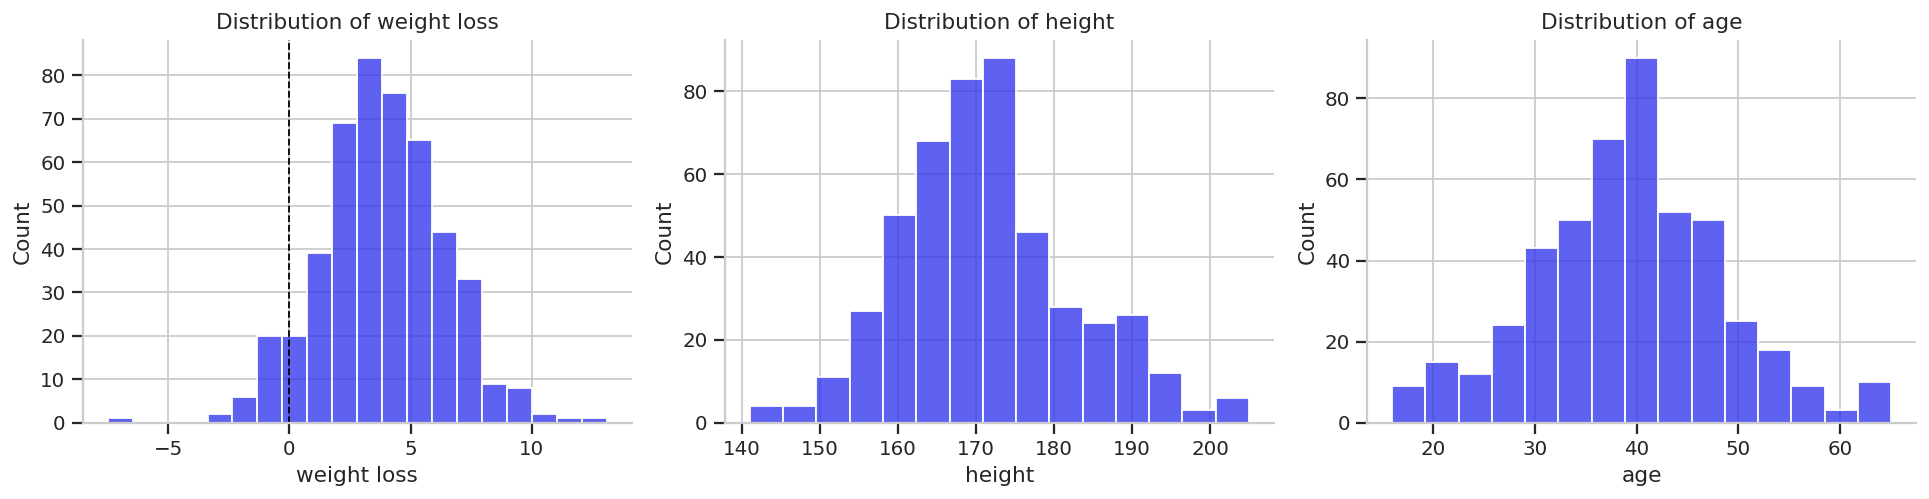

/tmp/ipykernel_867/1749932911.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


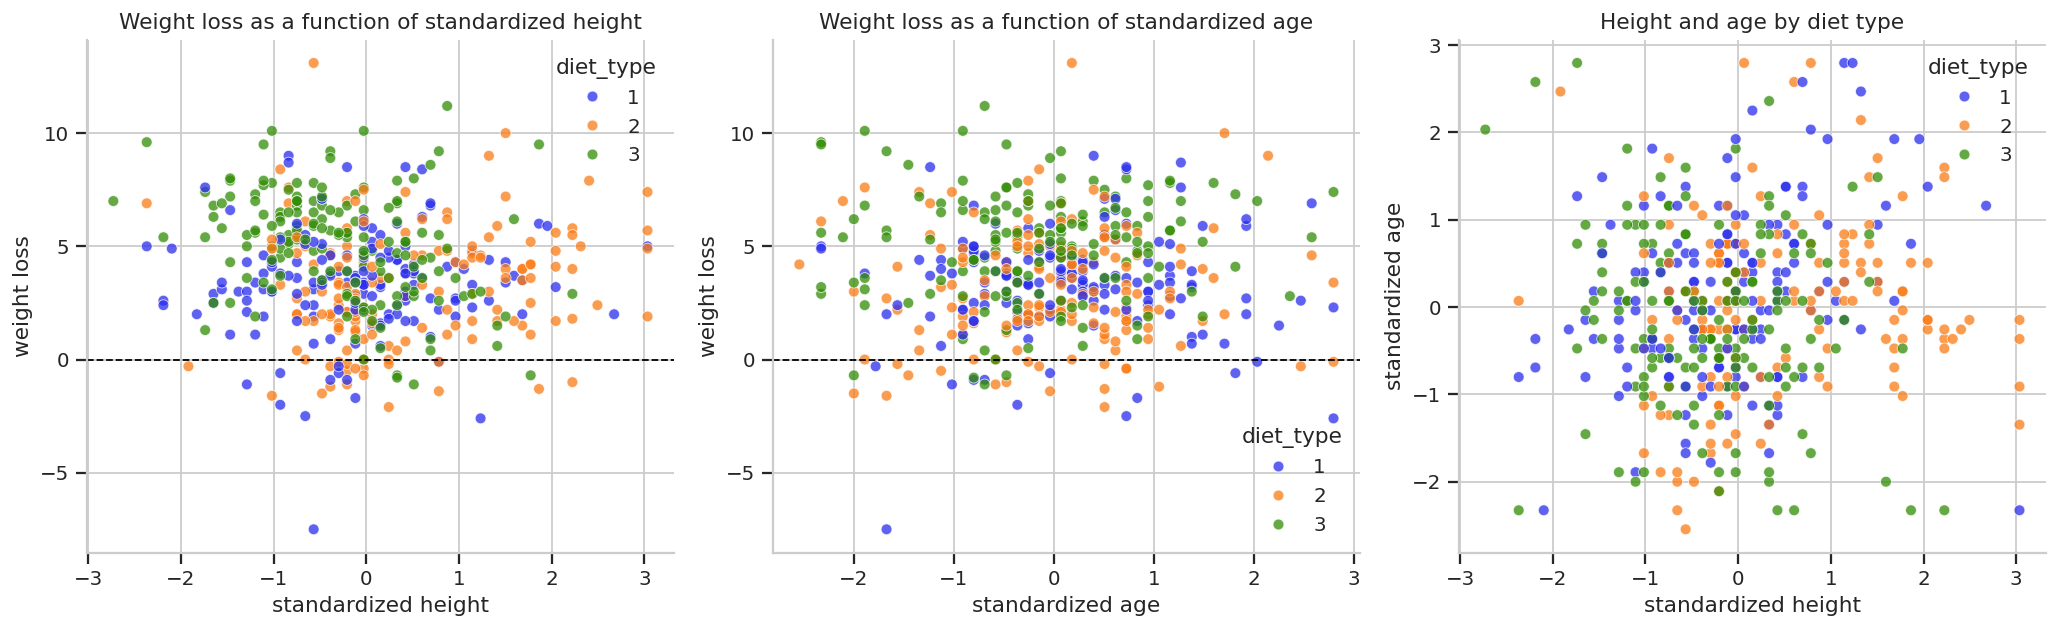

In [5]:
summary_table = food[["weight_loss", "height", "age", "weight_before", "weight_after"]].describe().T
summary_table = summary_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
display(summary_table.round(3))

print("Diet type counts")
display(food["diet_type"].value_counts().sort_index().to_frame("count"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(food["weight_loss"], bins=20, ax=axes[0], edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of weight loss")
axes[0].set_xlabel("weight loss")

sns.histplot(food["height"], bins=15, ax=axes[1], edgecolor="white")
axes[1].set_title("Distribution of height")
axes[1].set_xlabel("height")

sns.histplot(food["age"], bins=15, ax=axes[2], edgecolor="white")
axes[2].set_title("Distribution of age")
axes[2].set_xlabel("age")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=food, x="height_z", y="weight_loss", hue="diet_type", ax=axes[0], alpha=0.75)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Weight loss as a function of standardized height")
axes[0].set_xlabel("standardized height")
axes[0].set_ylabel("weight loss")

sns.scatterplot(data=food, x="age_z", y="weight_loss", hue="diet_type", ax=axes[1], alpha=0.75)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Weight loss as a function of standardized age")
axes[1].set_xlabel("standardized age")
axes[1].set_ylabel("weight loss")

sns.scatterplot(data=food, x="height_z", y="age_z", hue="diet_type", ax=axes[2], alpha=0.75)
axes[2].set_title("Height and age by diet type")
axes[2].set_xlabel("standardized height")
axes[2].set_ylabel("standardized age")

plt.tight_layout()
plt.show()


# Part A — Why model comparison?

In Tutorial 8, we used explained-variance summaries such as \(R^2\), partial \(R^2\), \(\eta^2\), and Cohen's \(f\).

Those summaries help answer questions such as:

> How much variation does the model or term explain?

Model comparison asks a different question:

> Which candidate model is expected to predict new observations better?

A model can explain more variation in the observed data simply because it is more flexible. This can lead to overfitting. Model comparison criteria try to estimate out-of-sample predictive performance: performance on data that were not used to fit the model.

## Model comparison inside the Bayesian workflow

Model comparison should not be done before checking the models.

For each candidate model, we first run the Bayesian workflow:

1. Define the model.
2. Check the prior predictive distribution.
3. Sample from the posterior.
4. Check sampling diagnostics.
5. Interpret the posterior.
6. Check the posterior predictive distribution.
7. Only then compare predictive accuracy.

The comparison table does not replace diagnostics, posterior predictive checks, or scientific interpretation.

## 5. Candidate models

All candidate models are Gaussian regression models for `weight_loss`.

The models differ only in their linear predictor for \(\mu_i\).

In [6]:
candidate_formulas = {
    "intercept only": "weight_loss ~ 1",
    "height only": "weight_loss ~ height_z",
    "height + age": "weight_loss ~ height_z + age_z",
    "height * age": "weight_loss ~ height_z * age_z",
    "height * age + diet": "weight_loss ~ height_z * age_z + diet_type",
}

candidate_model_table = pd.DataFrame({
    "model": list(candidate_formulas.keys()),
    "formula": list(candidate_formulas.values()),
    "question": [
        "How well can we predict weight loss with no predictors?",
        "Does height improve prediction relative to the intercept-only model?",
        "Does age add predictive information beyond height?",
        "Does the height effect depend on age?",
        "Does diet type add predictive information after height, age, and their interaction?",
    ],
})

display(candidate_model_table)


,model,formula,question
0,intercept only,weight_loss ~ 1,How well can we predict weight loss with no pr...
1,height only,weight_loss ~ height_z,Does height improve prediction relative to the...
2,height + age,weight_loss ~ height_z + age_z,Does age add predictive information beyond hei...
3,height * age,weight_loss ~ height_z * age_z,Does the height effect depend on age?
4,height * age + diet,weight_loss ~ height_z * age_z + diet_type,Does diet type add predictive information afte...


## 6. Technical requirement for WAIC and LOO

WAIC and LOO require the **pointwise log likelihood**.

For Bambi models, we store it during sampling with:

```python
idata_kwargs={"log_likelihood": True}
```

If this is not included, ArviZ will not have the information needed to calculate WAIC or LOO.

## 7. Small helper for divergences

This function only prints the number of divergent transitions. It does not replace the diagnostic checks.

In [7]:
def print_divergences(idata, model_name):
    if "sample_stats" not in idata.groups():
        print(f"No sample_stats group found for {model_name}.")
        return
    n_divergences = int(idata.sample_stats["diverging"].sum().values)
    print(f"Number of divergences in {model_name}: {n_divergences}")

# Part B — Bayesian workflow for each candidate model

## 8. Model 1 — intercept only

Formula:

```text
weight_loss ~ 1
```

Question:

> How well can we predict weight loss with no predictors?

This model estimates one overall expected weight loss for all participants.

In [8]:
# ------------------------------------------------------------
# Bayesian model 1: intercept only
# ------------------------------------------------------------

intercept_model = bmb.Model(
    "weight_loss ~ 1",
    data=food,
    family="gaussian",
)

print(intercept_model)

       Formula: weight_loss ~ 1
        Family: gaussian
          Link: mu = identity
  Observations: 480
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 3.8506, sigma: 6.3234)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.5294)


### Model 1 — Prior predictive check

Before fitting, check what the model expects to see before observing the data.

/usr/local/lib/python3.12/dist-packages/pymc/backends/arviz.py:71: UserWarning: Incompatible coordinate length of 480 for dimension '__obs__' of variable 'mu'.
This usually happens when a sliced or concatenated variable is wrapped as a `pymc.dims.Deterministic`.The originate coordinates for this dim will not be included in the returned dataset for any of the variables. Instead they will default to `np.arange(var_length)` and the shorter variables will be right-padded with nan.
To make this warning into an error set `pymc.backends.arviz.RAISE_ON_INCOMPATIBLE_COORD_LENGTHS` to `True`
  warnings.warn(


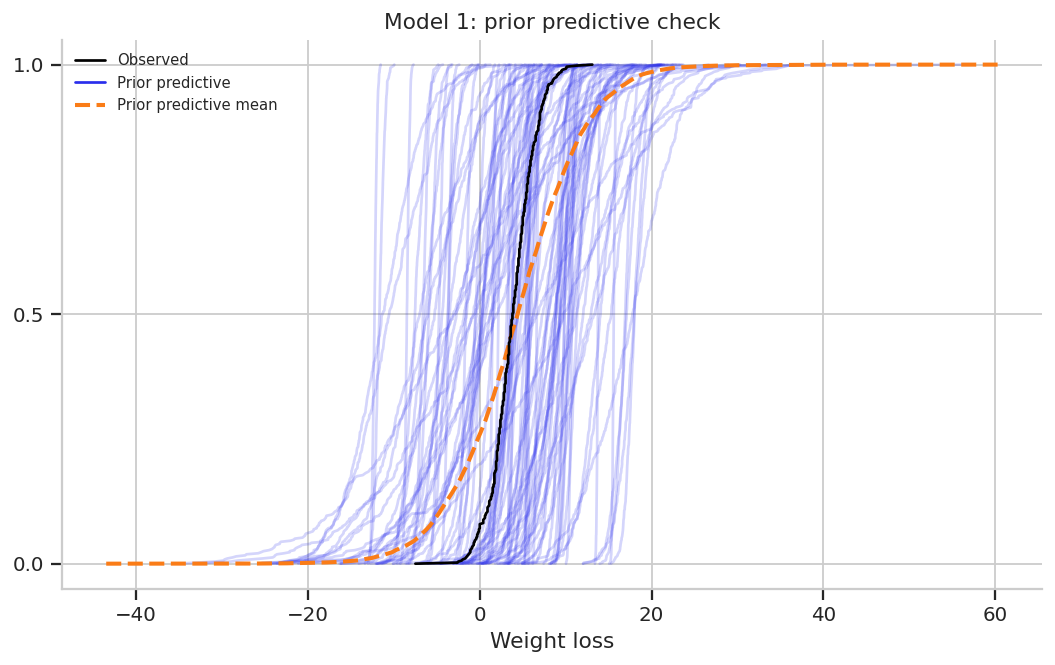

In [9]:
intercept_model.build()

prior_intercept = intercept_model.prior_predictive(
    draws=1000,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    prior_intercept,
    group="prior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 1: prior predictive check")
plt.xlabel("Weight loss")
plt.show()

### Model 1 — Sample the posterior

Important: `idata_kwargs={"log_likelihood": True}` is required for WAIC and LOO later.

In [10]:
idata_intercept = intercept_model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
    idata_kwargs={"log_likelihood": True},
)

Output()

### Model 1 — Sampling diagnostics

Number of divergences in Model 1: intercept only: 0


/tmp/ipykernel_867/2394255948.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


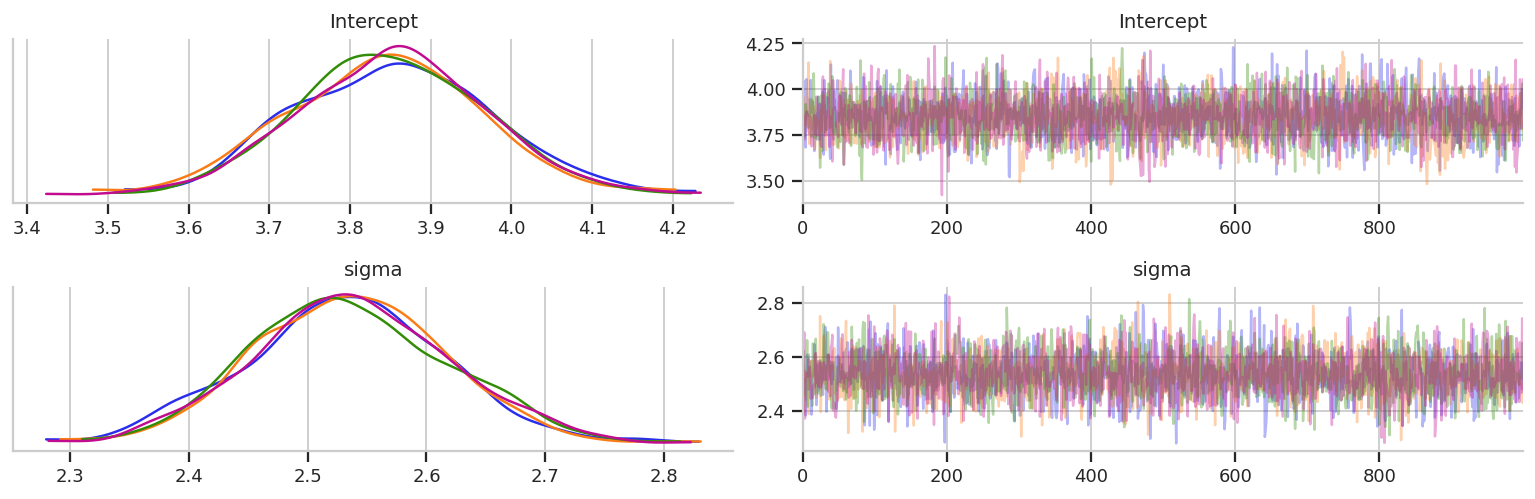

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,3510.0,2393.0,1.0
sigma,0.0,0.0,3903.0,2829.0,1.0


In [11]:
print_divergences(idata_intercept, "Model 1: intercept only")

az.plot_trace(
    idata_intercept,
    compact=False,
)

plt.tight_layout()
plt.show()

az.summary(
    idata_intercept,
    kind="diagnostics",
).round(2)

### Model 1 — Posterior summary

In [12]:
az.summary(
    idata_intercept,
    hdi_prob=HDI_MASS,
    kind="stats",
).round(3)

,mean,sd,hdi_3%,hdi_97%
Intercept,3.850,0.118,3.621,4.061
sigma,2.535,0.082,2.383,2.691


### Model 1 — Posterior predictions: intercept only

This plot shows each participant's observed weight loss by observation index.

The intercept-only model gives the same expected prediction for every observation. The horizontal line is the posterior mean prediction, and the shaded band is the posterior uncertainty around that expected value. The x-axis is only the observation index; it is not a predictor in the model.

/tmp/ipykernel_867/4059758750.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


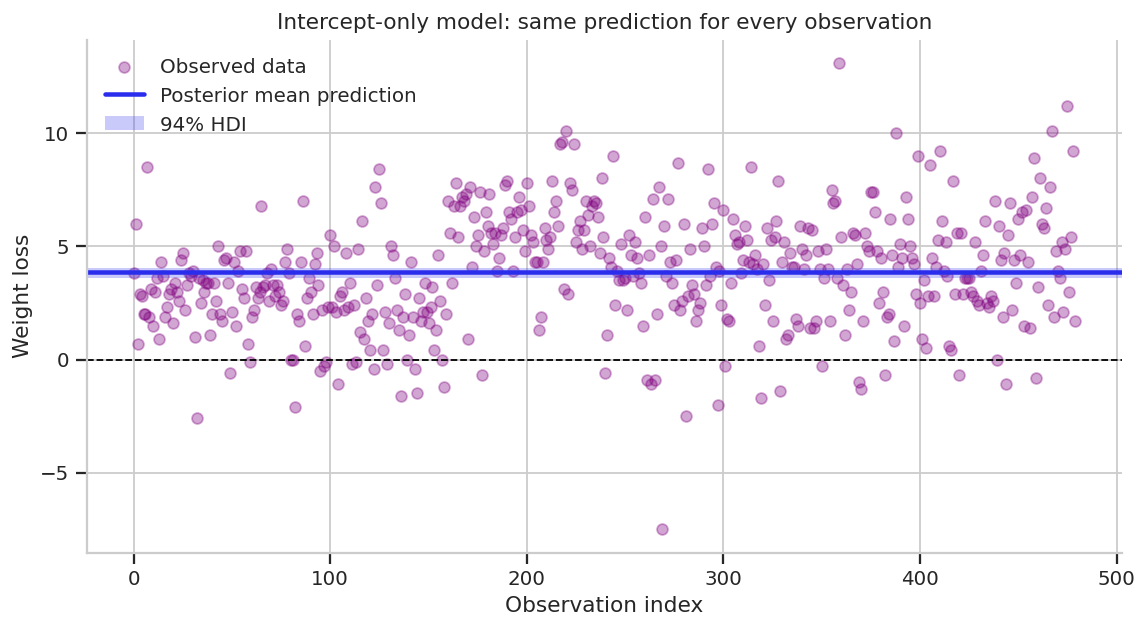

In [13]:
posterior_intercept = (
    idata_intercept.posterior["Intercept"]
    .stack(sample=("chain", "draw"))
    .values
)

posterior_intercept_mean = posterior_intercept.mean()
posterior_intercept_hdi = az.hdi(posterior_intercept, hdi_prob=HDI_MASS)

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    np.arange(len(food)),
    food["weight_loss"],
    alpha=0.35,
    color="purple",
    label="Observed data",
)

ax.axhline(
    posterior_intercept_mean,
    linewidth=2.5,
    label="Posterior mean prediction",
)

ax.axhspan(
    posterior_intercept_hdi[0],
    posterior_intercept_hdi[1],
    alpha=0.25,
    label=f"{int(HDI_MASS * 100)}% HDI",
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_title("Intercept-only model: same prediction for every observation")
ax.set_xlabel("Observation index")
ax.set_ylabel("Weight loss")
ax.legend()

plt.tight_layout()
plt.show()

### Model 1 — Posterior predictive check

This checks whether the fitted model generates weight-loss values similar to the observed values.

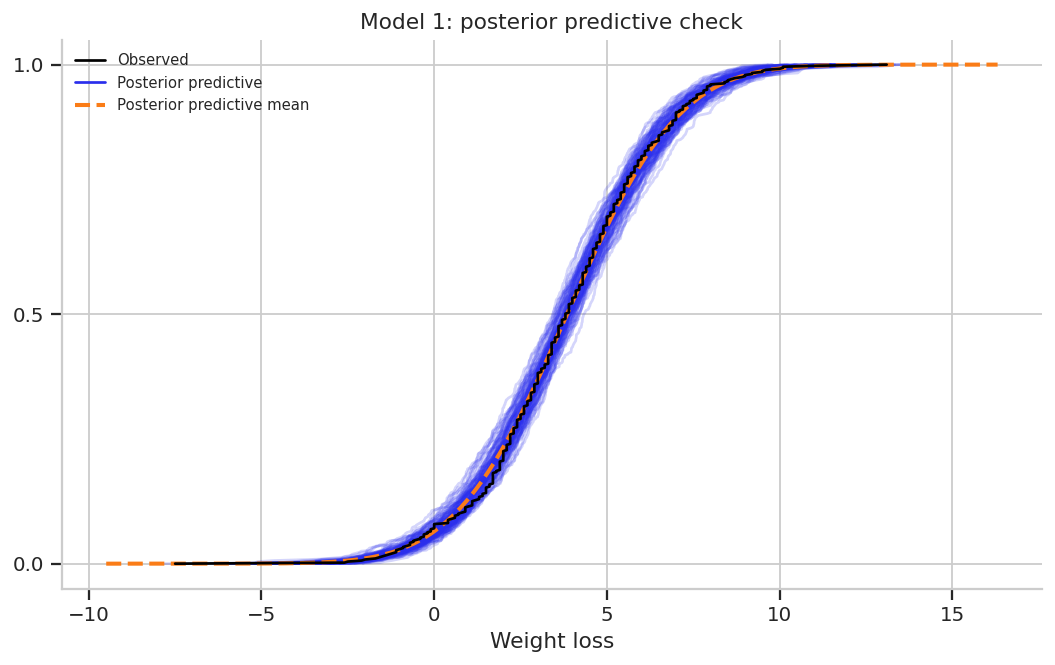

In [14]:
intercept_model.predict(
    idata_intercept,
    kind="pps",
    inplace=True,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    idata_intercept,
    group="posterior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 1: posterior predictive check")
plt.xlabel("Weight loss")
plt.show()

### Model 1 — Interpretation notes

This model is useful as a baseline. It asks how much predictive performance we get from the overall mean alone.

If the later models do not improve much over this model, the predictors may not add much predictive information.

### ArviZ WAIC & LOO

These single-model summaries are kept here as an intermediate check before comparing models.

In [15]:
az.waic(idata_intercept).round(2)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,0
elpd_waic,-1128.754398
se,18.318632
p_waic,2.407639
n_samples,4000
n_data_points,480
warning,True
waic_i,[<xarray.DataArray 'waic_i' ()> Size: 8B\narra...
scale,log


In [16]:
az.loo(idata_intercept).round(2)

,0
elpd_loo,-1128.757168
se,18.318944
p_loo,2.410409
n_samples,4000
n_data_points,480
warning,False
loo_i,[<xarray.DataArray 'loo_i' ()> Size: 8B\narray...
pareto_k,[<xarray.DataArray 'pareto_shape' ()> Size: 8B...
scale,log
good_k,0.7


## 9. Model 2 — height only

Formula:

```text
weight_loss ~ height_z
```

Question:

> Does height improve prediction relative to a model with no predictors?

This model estimates a linear association between standardized height and expected weight loss.


In [17]:
# ------------------------------------------------------------
# Bayesian model 2: height only
# ------------------------------------------------------------

height_model = bmb.Model(
    "weight_loss ~ height_z",
    data=food,
    family="gaussian",
)

print(height_model)


       Formula: weight_loss ~ height_z
        Family: gaussian
          Link: mu = identity
  Observations: 480
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 3.8506, sigma: 6.3234)
            height_z ~ Normal(mu: 0.0, sigma: 6.33)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.5294)


### Model 2 — Prior predictive check

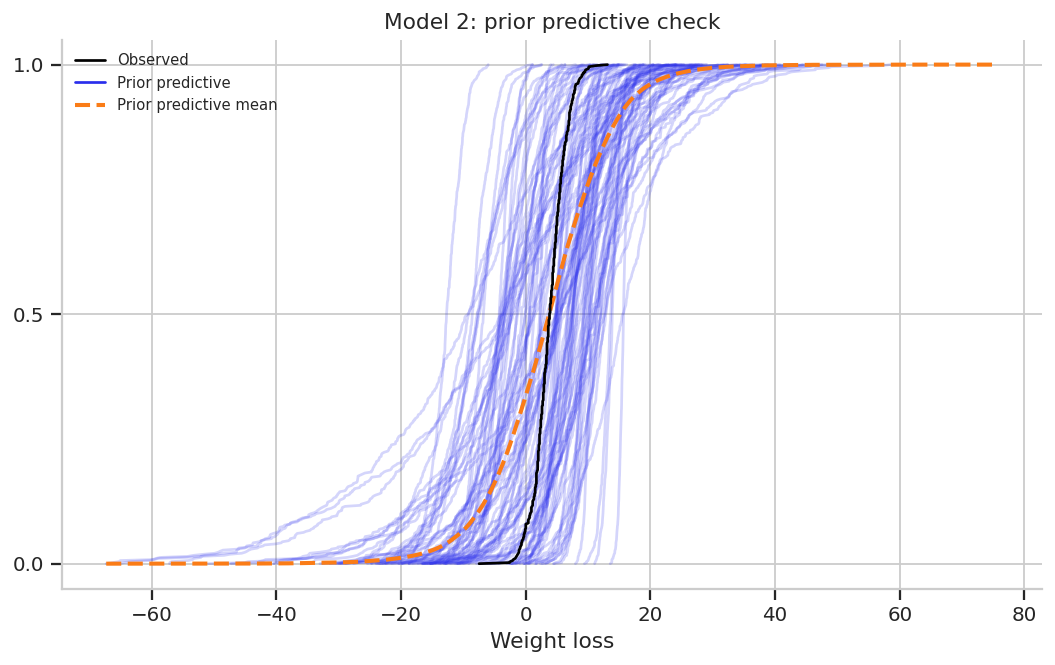

In [18]:
height_model.build()

prior_height = height_model.prior_predictive(
    draws=1000,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    prior_height,
    group="prior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 2: prior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 2 — Sample the posterior

In [19]:
idata_height = height_model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
    idata_kwargs={"log_likelihood": True},
)


Output()

### Model 2 — Sampling diagnostics

Number of divergences in Model 2: height only: 0


/tmp/ipykernel_867/2369419281.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


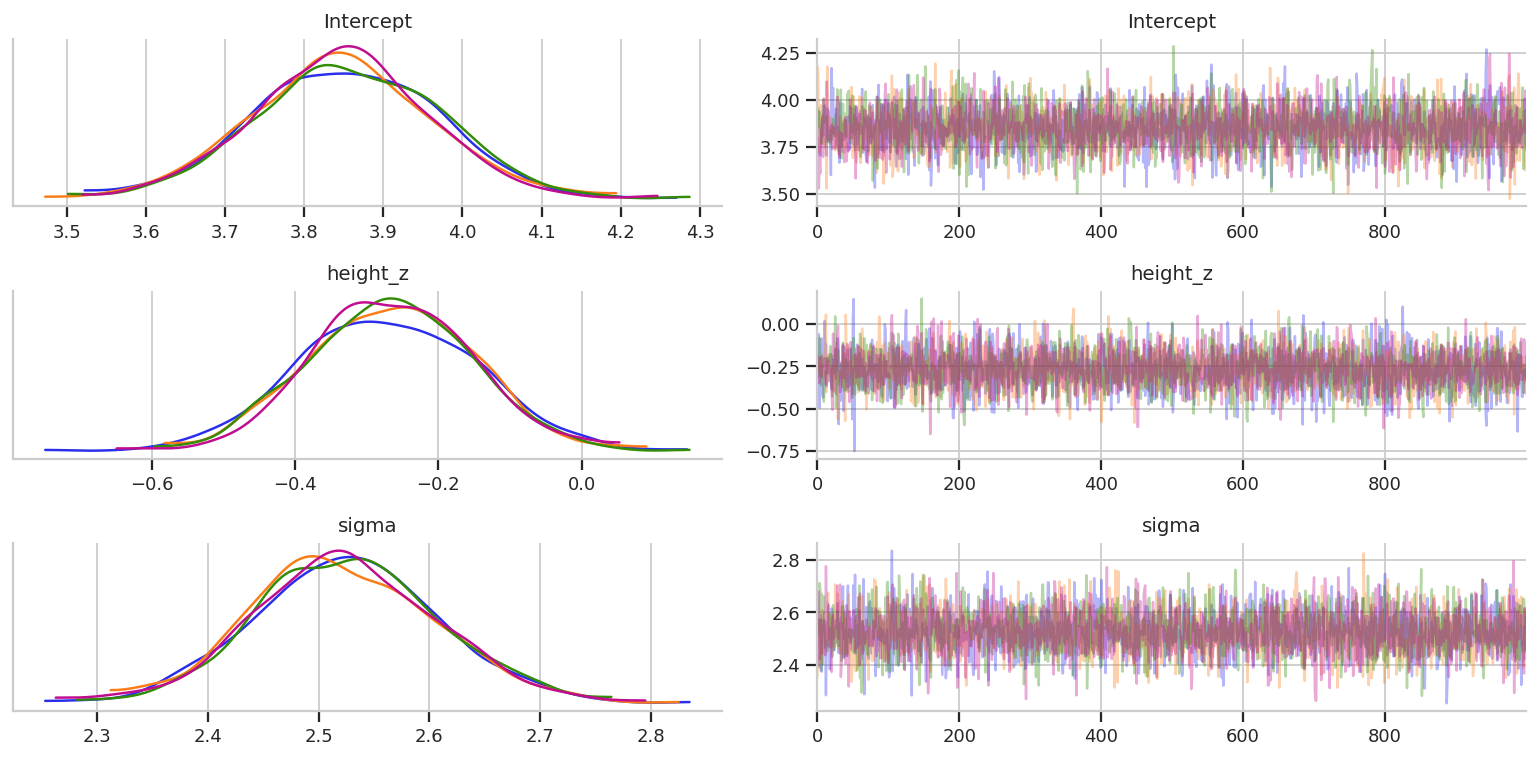

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,4250.0,3104.0,1.0
height_z,0.0,0.0,4631.0,3158.0,1.0
sigma,0.0,0.0,4163.0,3056.0,1.0


In [20]:
print_divergences(idata_height, "Model 2: height only")

az.plot_trace(
    idata_height,
    compact=False,
)

plt.tight_layout()
plt.show()

az.summary(
    idata_height,
    kind="diagnostics",
).round(2)


### Model 2 — Posterior summary

In [21]:
az.summary(
    idata_height,
    hdi_prob=HDI_MASS,
    kind="stats",
).round(3)


,mean,sd,hdi_3%,hdi_97%
Intercept,3.850,0.115,3.641,4.070
height_z,-0.267,0.115,-0.480,-0.052
sigma,2.524,0.083,2.372,2.686


### Model 2 — Posterior predictions

The posterior prediction line shows the expected weight loss as a function of standardized height.


/tmp/ipykernel_867/3900916123.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


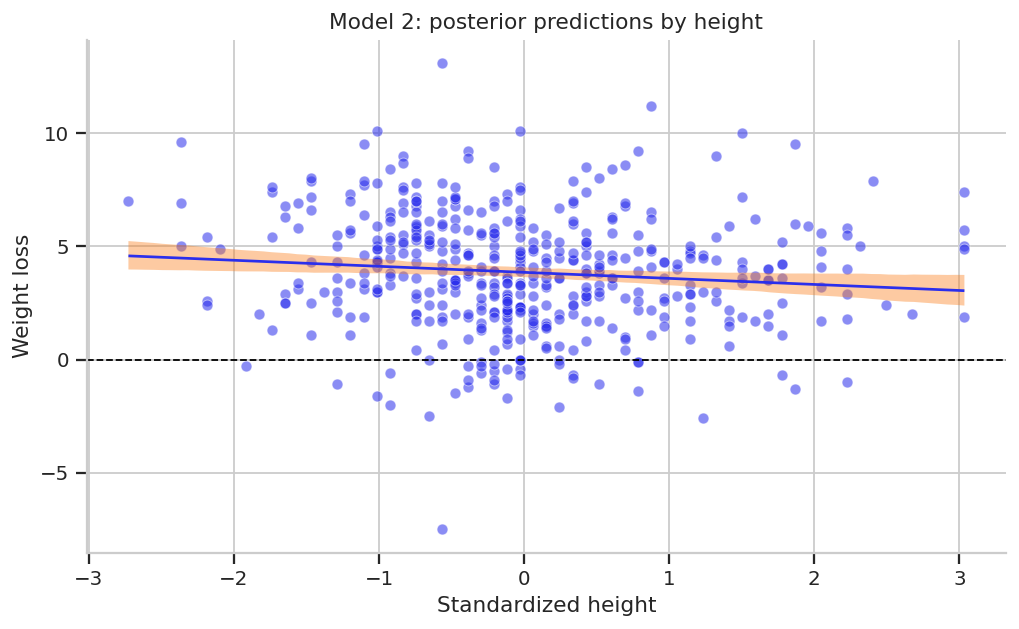

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=food,
    x="height_z",
    y="weight_loss",
    alpha=0.55,
    ax=ax,
)

bmb.interpret.plot_predictions(
    height_model,
    idata_height,
    conditional={"height_z": np.linspace(food["height_z"].min(), food["height_z"].max(), 100)},
    use_hdi=True,
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Model 2: posterior predictions by height")
ax.set_xlabel("Standardized height")
ax.set_ylabel("Weight loss")

plt.tight_layout()
plt.show()


### Model 2 — Posterior predictive check

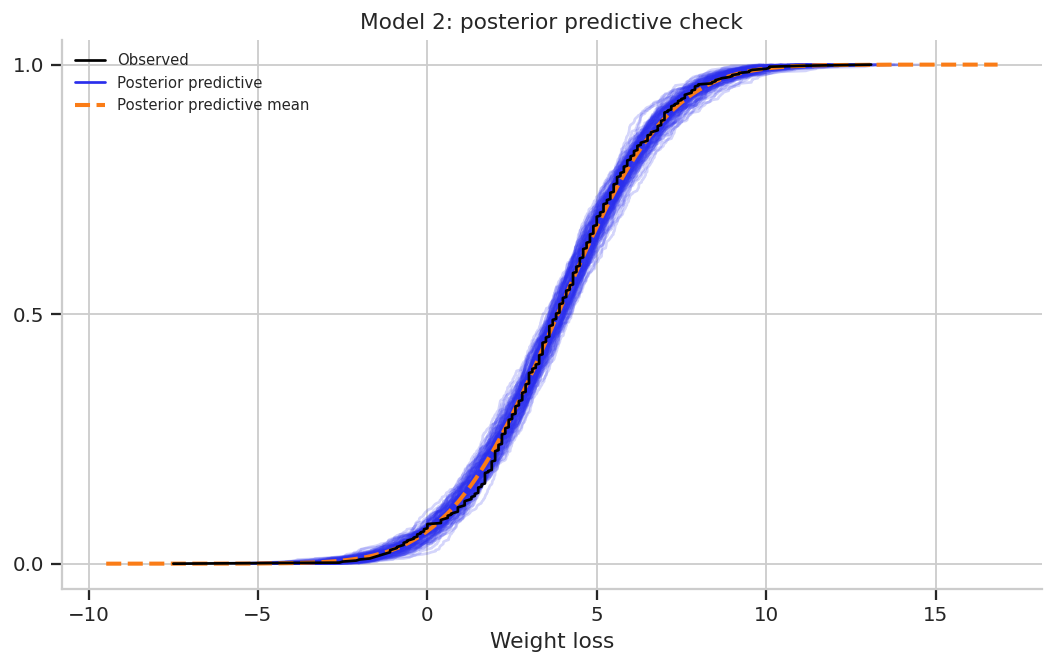

In [23]:
height_model.predict(
    idata_height,
    kind="pps",
    inplace=True,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    idata_height,
    group="posterior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 2: posterior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 2 — Interpretation notes

This model asks whether height alone captures useful differences in expected weight loss.

The coefficient for `height_z` is interpreted as the expected change in weight loss for a one-standard-deviation increase in height.

### Comparing models 1 & 2

This comparison is kept here as an intermediate comparison, before fitting the more complex models.


In [24]:
# Compare LOO
az.compare({"intercept_only": idata_intercept, "height_only": idata_height})


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
height_only,0,-1127.080533,3.412700,0.000000,0.815525,18.659916,0.000000,False,log
intercept_only,1,-1128.757168,2.410409,1.676635,0.184475,18.318944,2.306793,False,log


In [25]:
# Compare WAIC
az.compare({"intercept_only": idata_intercept, "height_only": idata_height}, ic="waic")


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
height_only,0,-1127.073841,3.406008,0.000000,0.816316,18.658446,0.000000,True,log
intercept_only,1,-1128.754398,2.407639,1.680557,0.183684,18.318632,2.306437,True,log


## 10. Model 3 — height + age

Formula:

```text
weight_loss ~ height_z + age_z
```

Question:

> Does age add predictive information beyond height?

This is an additive model. It assumes that height and age contribute separately.


In [26]:
# ------------------------------------------------------------
# Bayesian model 3: height + age
# ------------------------------------------------------------

height_age_model = bmb.Model(
    "weight_loss ~ height_z + age_z",
    data=food,
    family="gaussian",
)

print(height_age_model)


       Formula: weight_loss ~ height_z + age_z
        Family: gaussian
          Link: mu = identity
  Observations: 480
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 3.8506, sigma: 6.3234)
            height_z ~ Normal(mu: 0.0, sigma: 6.33)
            age_z ~ Normal(mu: 0.0, sigma: 6.33)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.5294)


### Model 3 — Prior predictive check

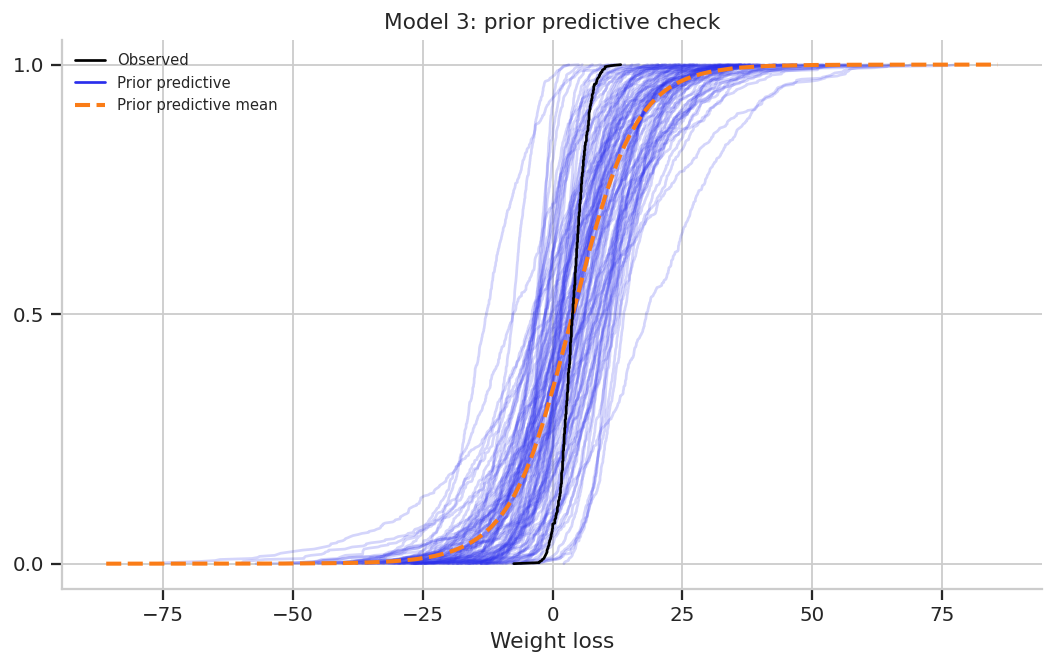

In [27]:
height_age_model.build()

prior_height_age = height_age_model.prior_predictive(
    draws=1000,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    prior_height_age,
    group="prior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 3: prior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 3 — Sample the posterior

In [28]:
idata_height_age = height_age_model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
    idata_kwargs={"log_likelihood": True},
)


Output()

### Model 3 — Sampling diagnostics

Number of divergences in Model 3: height + age: 0


/tmp/ipykernel_867/3701220736.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


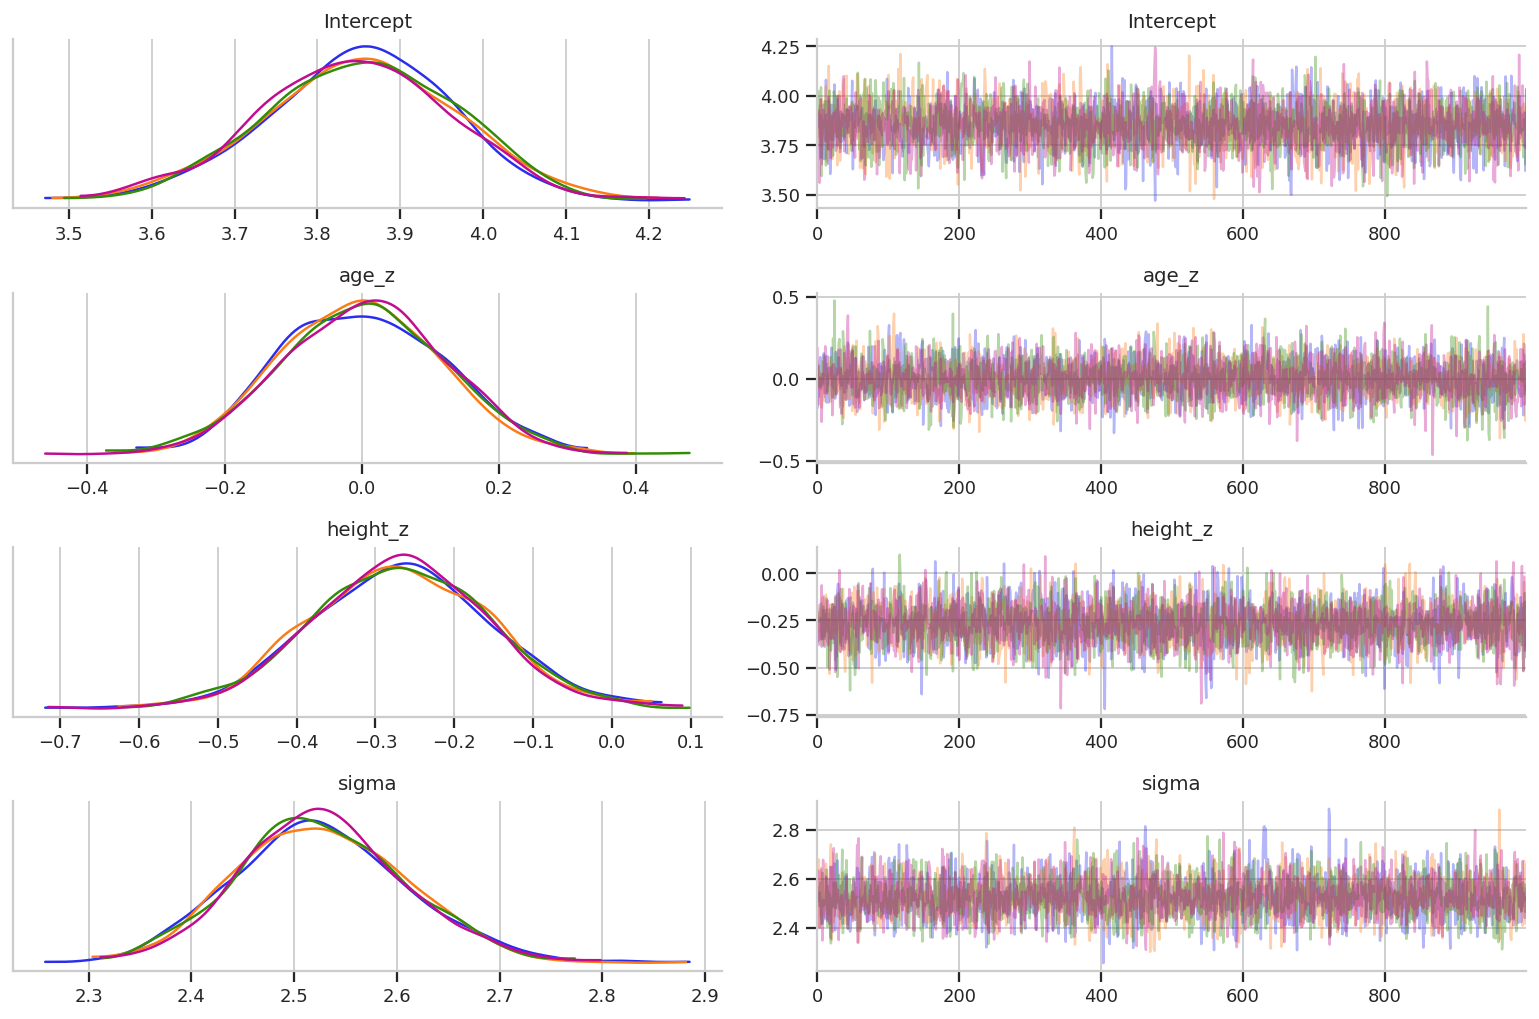

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,4513.0,3093.0,1.0
age_z,0.0,0.0,4524.0,3119.0,1.0
height_z,0.0,0.0,4388.0,3253.0,1.0
sigma,0.0,0.0,4774.0,3020.0,1.0


In [29]:
print_divergences(idata_height_age, "Model 3: height + age")

az.plot_trace(
    idata_height_age,
    compact=False,
)

plt.tight_layout()
plt.show()

az.summary(
    idata_height_age,
    kind="diagnostics",
).round(2)


### Model 3 — Posterior summary

In [30]:
az.summary(
    idata_height_age,
    hdi_prob=HDI_MASS,
    kind="stats",
).round(3)


,mean,sd,hdi_3%,hdi_97%
Intercept,3.849,0.115,3.627,4.057
age_z,0.001,0.118,-0.214,0.220
height_z,-0.269,0.113,-0.476,-0.057
sigma,2.527,0.082,2.376,2.681


### Model 3 — Posterior predictions

The model includes two continuous predictors. A two-dimensional plot can show only one predictor on the x-axis.

Here we show predictions across height while fixing age at three standardized values:

\[
age_z = -1, 0, 1
\]

Because this is an additive model, the predicted lines should be parallel.


/tmp/ipykernel_867/1011417610.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


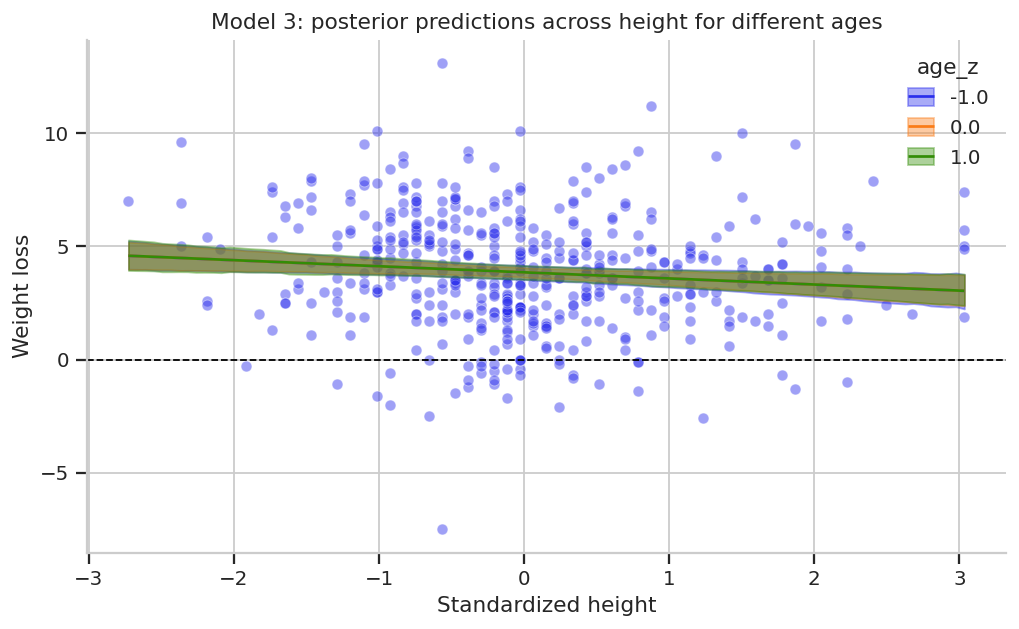

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=food,
    x="height_z",
    y="weight_loss",
    alpha=0.45,
    ax=ax,
)

bmb.interpret.plot_predictions(
    height_age_model,
    idata_height_age,
    conditional={
        "height_z": np.linspace(food["height_z"].min(), food["height_z"].max(), 100),
        "age_z": [-1, 0, 1],
    },
    use_hdi=True,
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Model 3: posterior predictions across height for different ages")
ax.set_xlabel("Standardized height")
ax.set_ylabel("Weight loss")

plt.tight_layout()
plt.show()


### Model 3 — Posterior predictive check

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


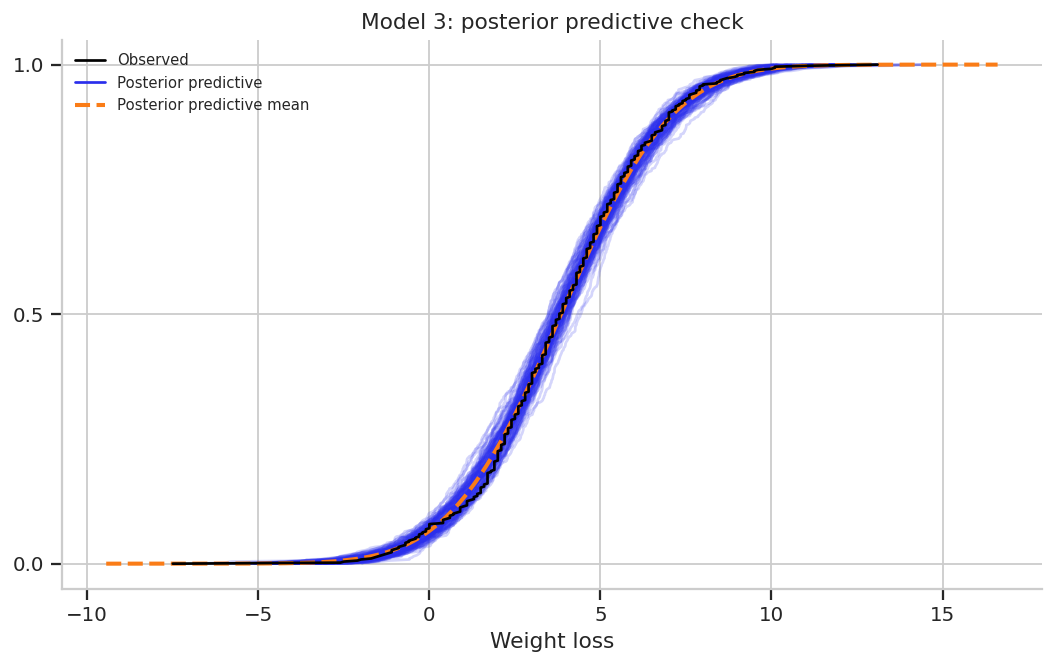

In [32]:
height_age_model.predict(
    idata_height_age,
    kind="pps",
    inplace=True,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    idata_height_age,
    group="posterior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 3: posterior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 3 — Interpretation notes

This model estimates additive effects of height and age. It assumes that the slope of height does not depend on age, and the slope of age does not depend on height.


## 11. Model 4 — height × age interaction

Formula:

```text
weight_loss ~ height_z * age_z
```

Equivalent structure:

```text
weight_loss ~ height_z + age_z + height_z:age_z
```

Question:

> Does the height effect depend on age?

This model allows the association between height and weight loss to change as age changes.


In [33]:
# ------------------------------------------------------------
# Bayesian model 4: height * age
# ------------------------------------------------------------

height_age_interaction_model = bmb.Model(
    "weight_loss ~ height_z * age_z",
    data=food,
    family="gaussian",
)

print(height_age_interaction_model)


       Formula: weight_loss ~ height_z * age_z
        Family: gaussian
          Link: mu = identity
  Observations: 480
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 3.8506, sigma: 6.3405)
            height_z ~ Normal(mu: 0.0, sigma: 6.33)
            age_z ~ Normal(mu: 0.0, sigma: 6.33)
            height_z:age_z ~ Normal(mu: 0.0, sigma: 5.5828)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.5294)


### Model 4 — Prior predictive check

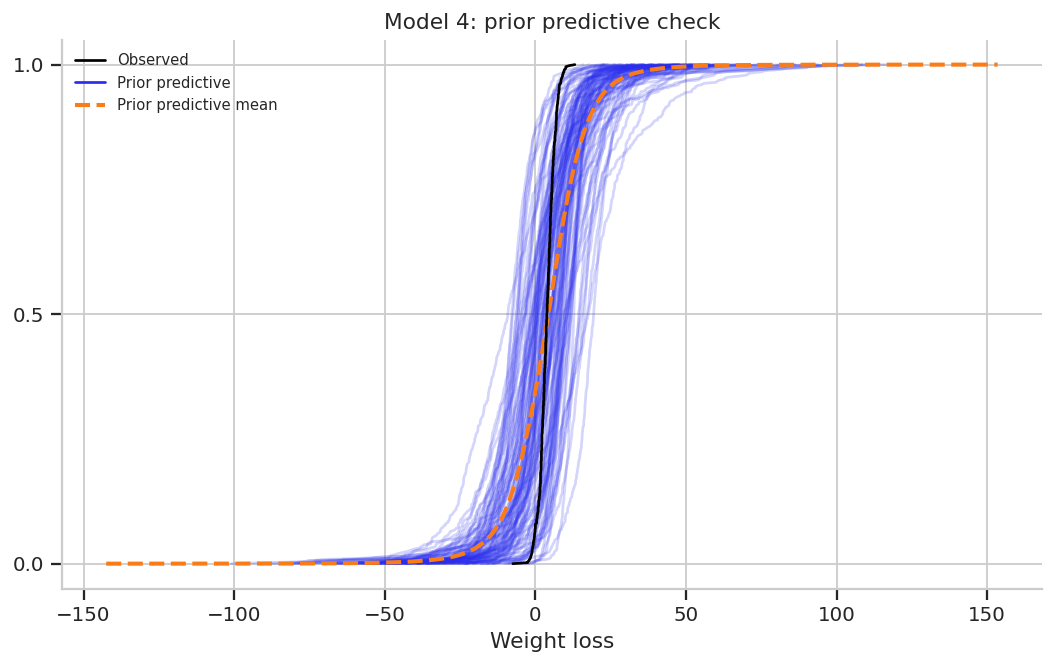

In [34]:
height_age_interaction_model.build()

prior_height_age_interaction = height_age_interaction_model.prior_predictive(
    draws=1000,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    prior_height_age_interaction,
    group="prior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 4: prior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 4 — Sample the posterior

In [35]:
idata_height_age_interaction = height_age_interaction_model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
    idata_kwargs={"log_likelihood": True},
)


Output()

### Model 4 — Sampling diagnostics

Number of divergences in Model 4: height * age: 0


/tmp/ipykernel_867/1102832487.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


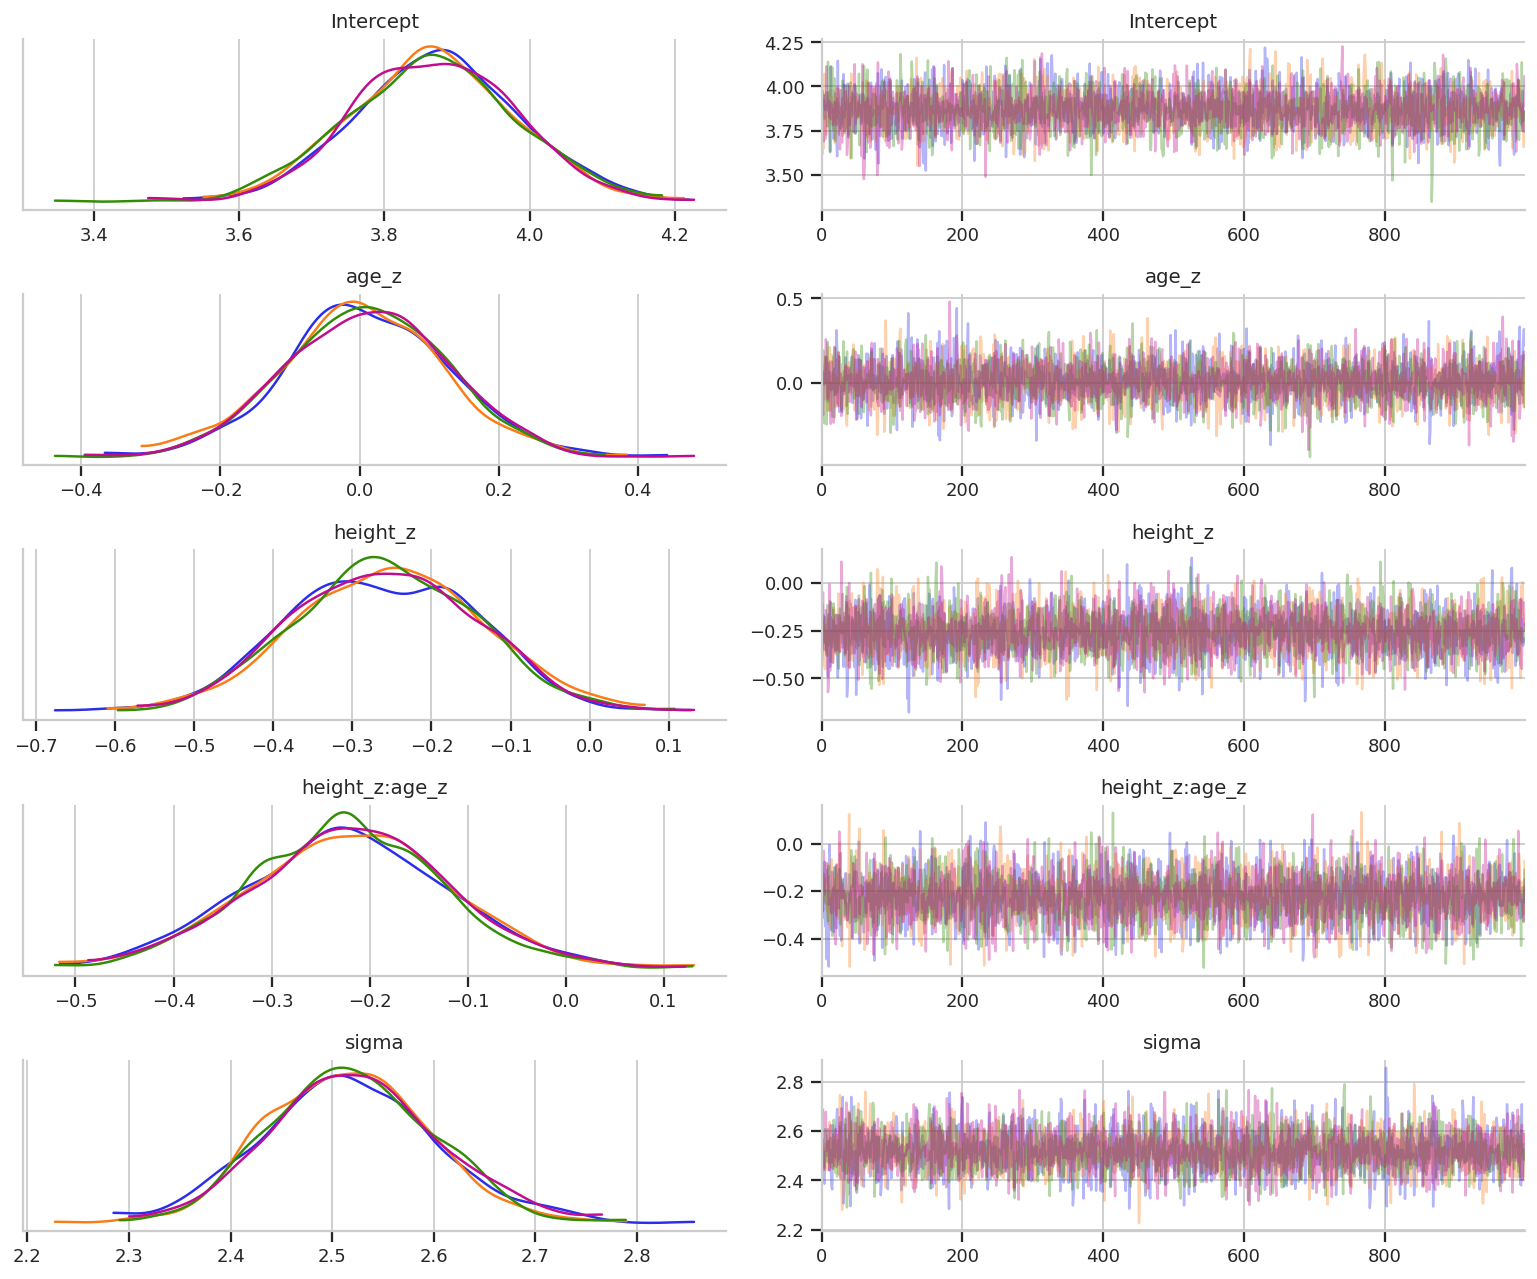

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,4829.0,2882.0,1.0
age_z,0.0,0.0,5184.0,3364.0,1.0
height_z,0.0,0.0,4979.0,2919.0,1.0
height_z:age_z,0.0,0.0,5278.0,3548.0,1.0
sigma,0.0,0.0,5135.0,3154.0,1.0


In [36]:
print_divergences(idata_height_age_interaction, "Model 4: height * age")

az.plot_trace(
    idata_height_age_interaction,
    compact=False,
)

plt.tight_layout()
plt.show()

az.summary(
    idata_height_age_interaction,
    kind="diagnostics",
).round(2)


### Model 4 — Posterior summary

In [37]:
az.summary(
    idata_height_age_interaction,
    hdi_prob=HDI_MASS,
    kind="stats",
).round(3)


,mean,sd,hdi_3%,hdi_97%
Intercept,3.868,0.113,3.661,4.081
age_z,0.008,0.116,-0.218,0.222
height_z,-0.257,0.117,-0.482,-0.051
height_z:age_z,-0.222,0.100,-0.415,-0.038
sigma,2.518,0.081,2.372,2.676


### Model 4 — Posterior predictions

The interaction model allows the height slope to differ for different fixed values of age.

If the lines are not parallel, the interaction changes the predicted relationship between height and weight loss.


/tmp/ipykernel_867/2664127632.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


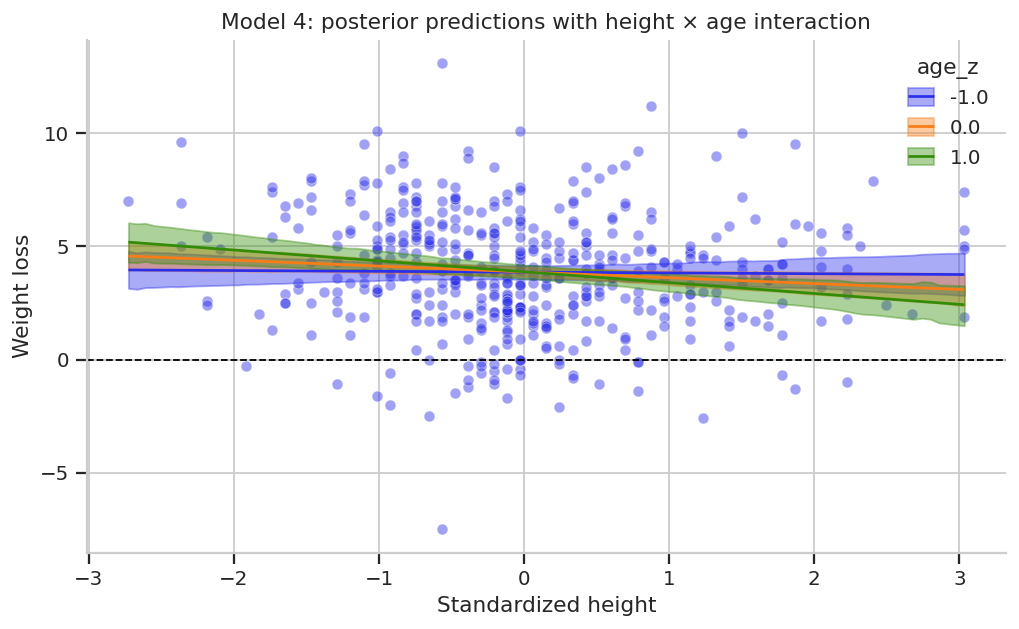

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=food,
    x="height_z",
    y="weight_loss",
    alpha=0.45,
    ax=ax,
)

bmb.interpret.plot_predictions(
    height_age_interaction_model,
    idata_height_age_interaction,
    conditional={
        "height_z": np.linspace(food["height_z"].min(), food["height_z"].max(), 100),
        "age_z": [-1, 0, 1],
    },
    use_hdi=True,
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Model 4: posterior predictions with height × age interaction")
ax.set_xlabel("Standardized height")
ax.set_ylabel("Weight loss")

plt.tight_layout()
plt.show()


### Model 4 — Posterior predictive check

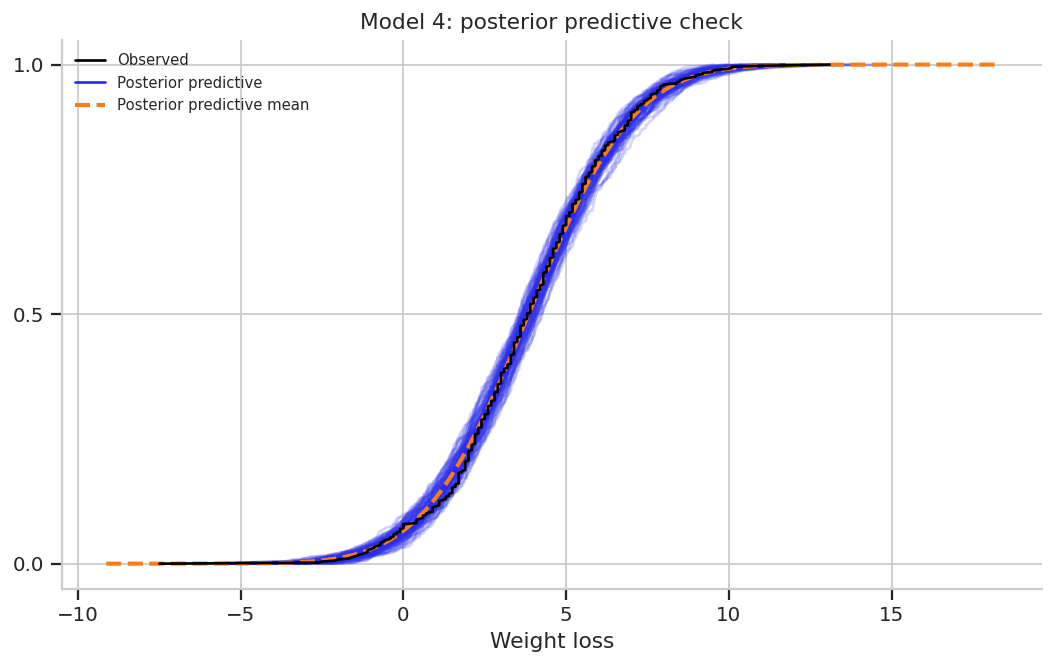

In [39]:
height_age_interaction_model.predict(
    idata_height_age_interaction,
    kind="pps",
    inplace=True,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    idata_height_age_interaction,
    group="posterior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 4: posterior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 4 — Interpretation notes

This model is more flexible than the additive height + age model. It should only be preferred if the added flexibility improves predictive performance enough, or if the interaction is scientifically important.


## 12. Model 5 — height × age + diet type

Formula:

```text
weight_loss ~ height_z * age_z + diet_type
```

Equivalent structure:

```text
weight_loss ~ height_z + age_z + height_z:age_z + diet_type
```

Question:

> Does diet type add predictive information after height, age, and their interaction?

This model includes the height-by-age interaction and an additive diet-type term.

It does **not** include interactions between diet type and height or age. Therefore, diet type is modeled as a shift in expected weight loss, while the height-by-age structure is shared across diet groups.


In [40]:
# ------------------------------------------------------------
# Bayesian model 5: height * age + diet type
# ------------------------------------------------------------

height_age_diet_model = bmb.Model(
    "weight_loss ~ height_z * age_z + diet_type",
    data=food,
    family="gaussian",
)

print(height_age_diet_model)


       Formula: weight_loss ~ height_z * age_z + diet_type
        Family: gaussian
          Link: mu = identity
  Observations: 480
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 3.8506, sigma: 8.9547)
            height_z ~ Normal(mu: 0.0, sigma: 6.33)
            age_z ~ Normal(mu: 0.0, sigma: 6.33)
            height_z:age_z ~ Normal(mu: 0.0, sigma: 5.5828)
            diet_type ~ Normal(mu: [0. 0.], sigma: [13.414 13.414])
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 2.5294)


### Model 5 — Prior predictive check

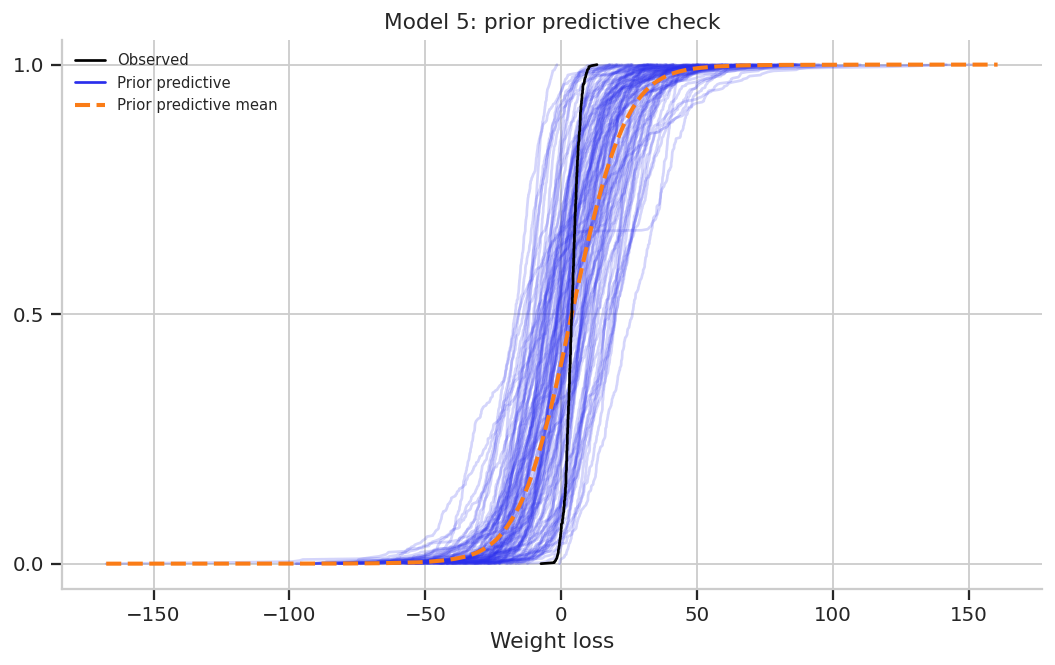

In [41]:
height_age_diet_model.build()

prior_height_age_diet = height_age_diet_model.prior_predictive(
    draws=1000,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    prior_height_age_diet,
    group="prior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 5: prior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 5 — Sample the posterior

In [42]:
idata_height_age_diet = height_age_diet_model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    random_seed=RANDOM_SEED,
    target_accept=0.9,
    idata_kwargs={"log_likelihood": True},
)


Output()

### Model 5 — Sampling diagnostics

Number of divergences in Model 5: height * age + diet type: 0


/tmp/ipykernel_867/1235468220.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


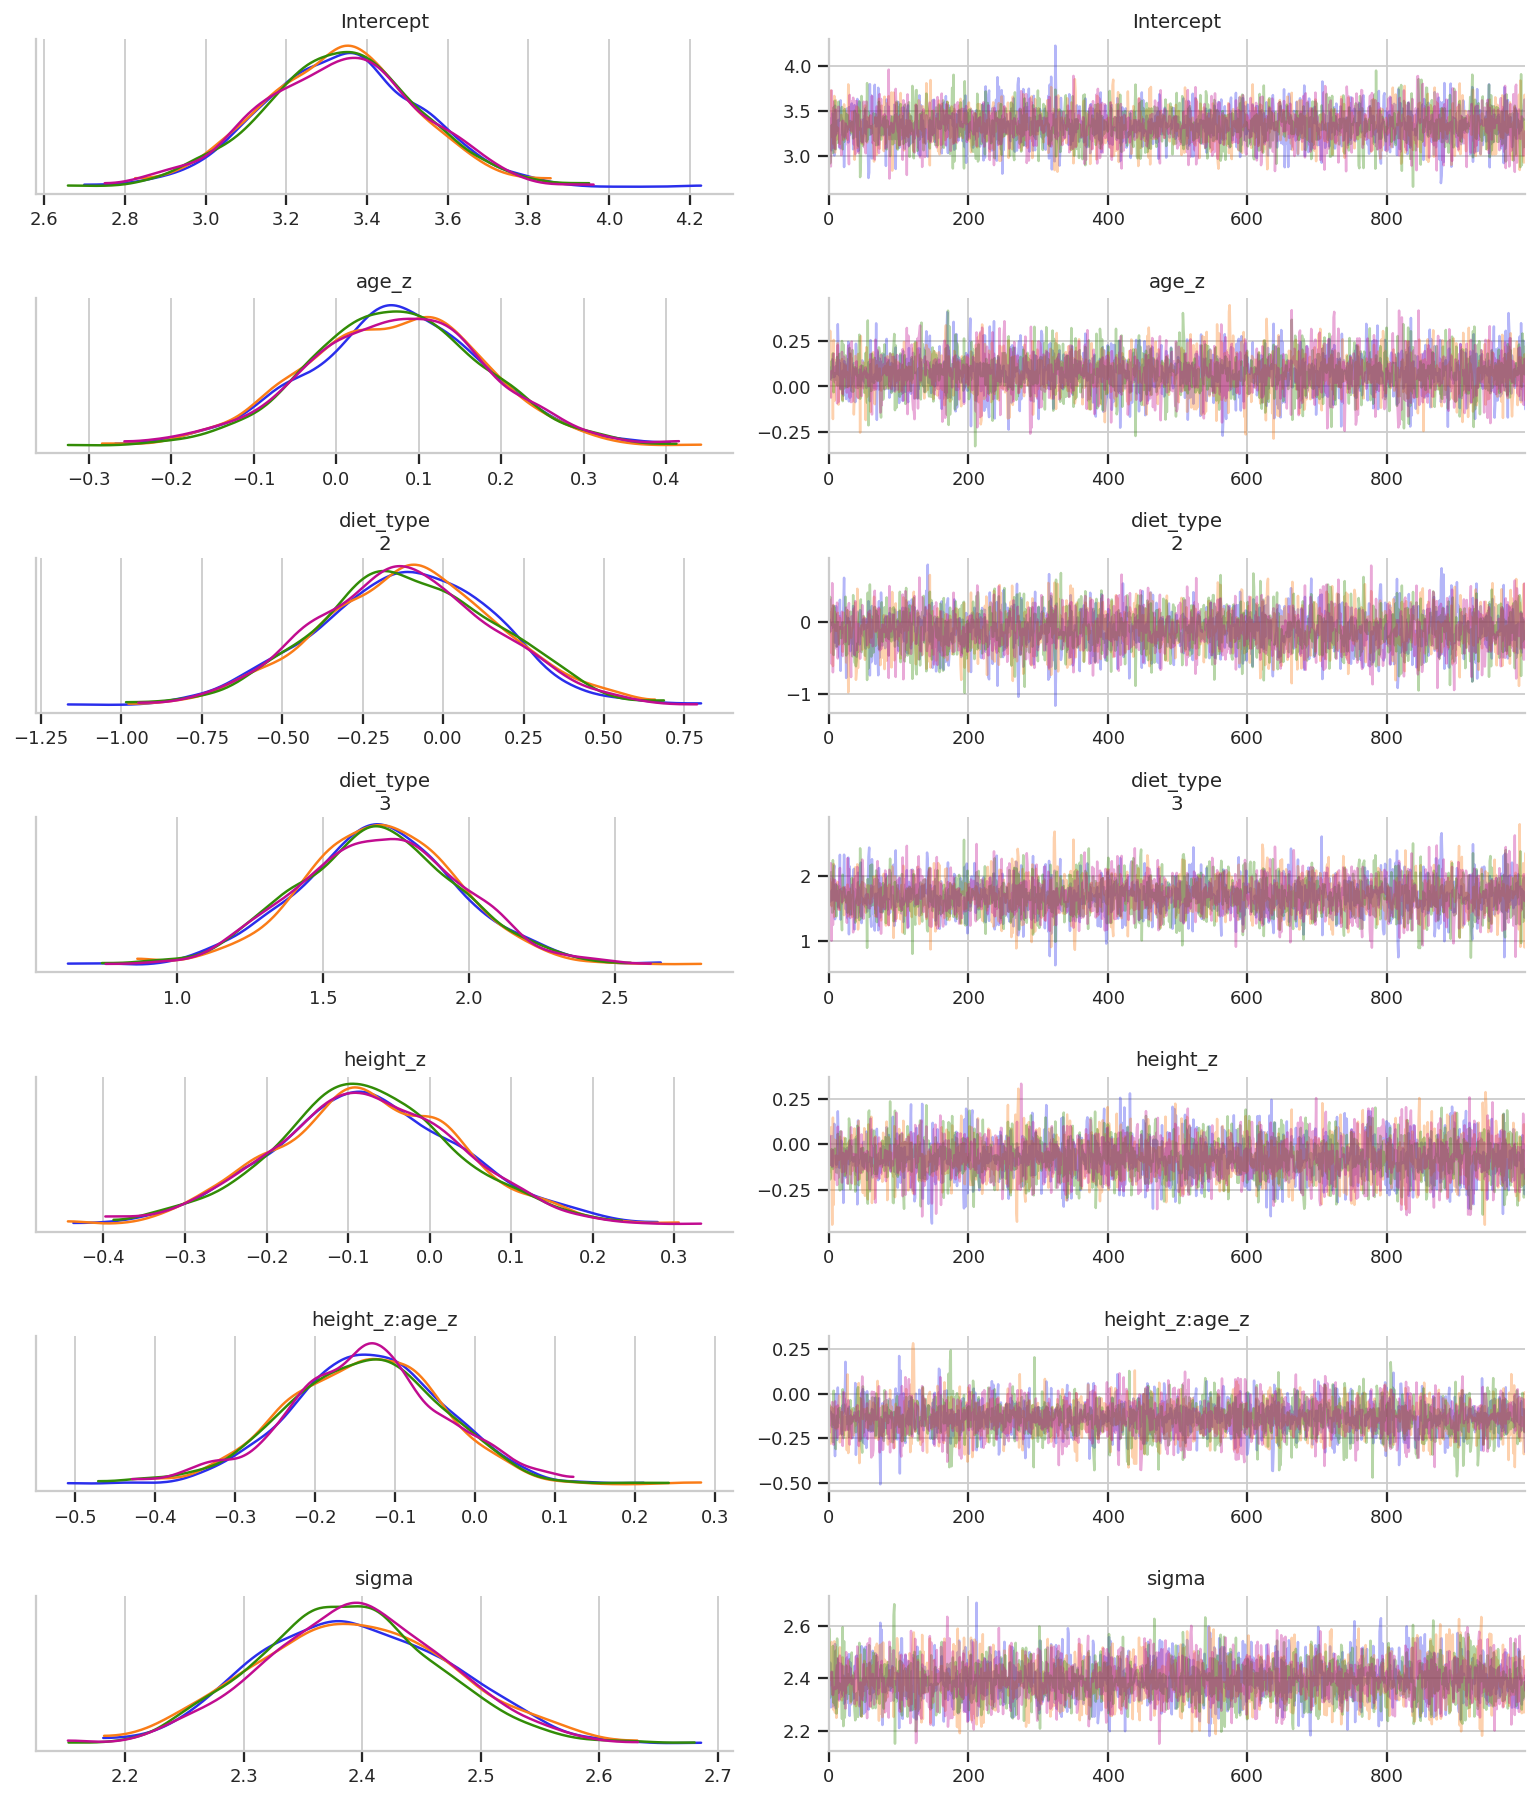

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.0,0.0,6323.0,3122.0,1.0
age_z,0.0,0.0,6454.0,2957.0,1.0
diet_type[2],0.0,0.0,5099.0,3263.0,1.0
diet_type[3],0.0,0.0,5864.0,2967.0,1.0
height_z,0.0,0.0,6474.0,2872.0,1.0
height_z:age_z,0.0,0.0,6177.0,2298.0,1.0
sigma,0.0,0.0,6191.0,2640.0,1.0


In [43]:
print_divergences(idata_height_age_diet, "Model 5: height * age + diet type")

az.plot_trace(
    idata_height_age_diet,
    compact=False,
)

plt.tight_layout()
plt.show()

az.summary(
    idata_height_age_diet,
    kind="diagnostics",
).round(2)


### Model 5 — Posterior summary

In [44]:
az.summary(
    idata_height_age_diet,
    hdi_prob=HDI_MASS,
    kind="stats",
).round(3)


,mean,sd,hdi_3%,hdi_97%
Intercept,3.334,0.193,2.971,3.698
age_z,0.072,0.108,-0.131,0.278
diet_type[2],-0.112,0.278,-0.658,0.379
diet_type[3],1.691,0.276,1.152,2.180
height_z,-0.077,0.113,-0.286,0.143
height_z:age_z,-0.138,0.096,-0.323,0.036
sigma,2.393,0.079,2.243,2.534


### Model 5 — Posterior predictions for the height × age interaction

This plot shows the height-by-age interaction while fixing diet type at the reference diet level.


/tmp/ipykernel_867/355946356.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


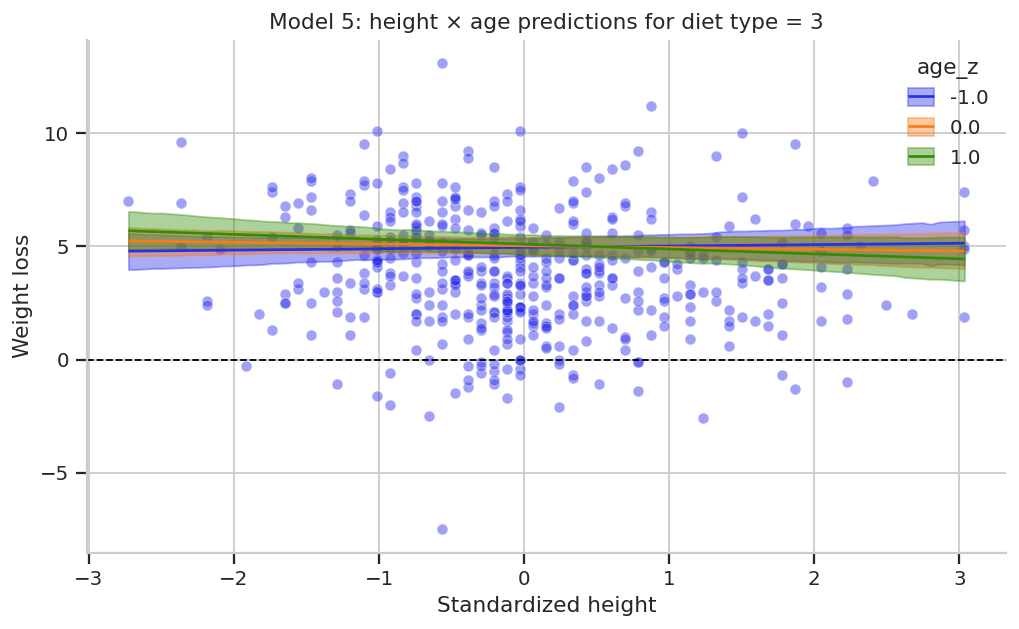

In [59]:
try:
    reference_diet = food["diet_type"].cat.categories[0] # choose diet type using index (0->type1, 1->type2, 2->type3)

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.scatterplot(
        data=food,
        x="height_z",
        y="weight_loss",
        alpha=0.45,
        ax=ax,
    )

    bmb.interpret.plot_predictions(
        height_age_diet_model,
        idata_height_age_diet,
        conditional={
            "height_z": np.linspace(food["height_z"].min(), food["height_z"].max(), 100),
            "age_z": [-1, 0, 1],
            "diet_type": [reference_diet],
        },
        use_hdi=True,
        ax=ax,
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Model 5: height × age predictions for diet type = {reference_diet}")
    ax.set_xlabel("Standardized height")
    ax.set_ylabel("Weight loss")

    plt.tight_layout()
    plt.show()

except Exception as error:
    print("Height-by-age prediction plot was skipped:")
    print(error)


### Model 5 — Posterior predictive check

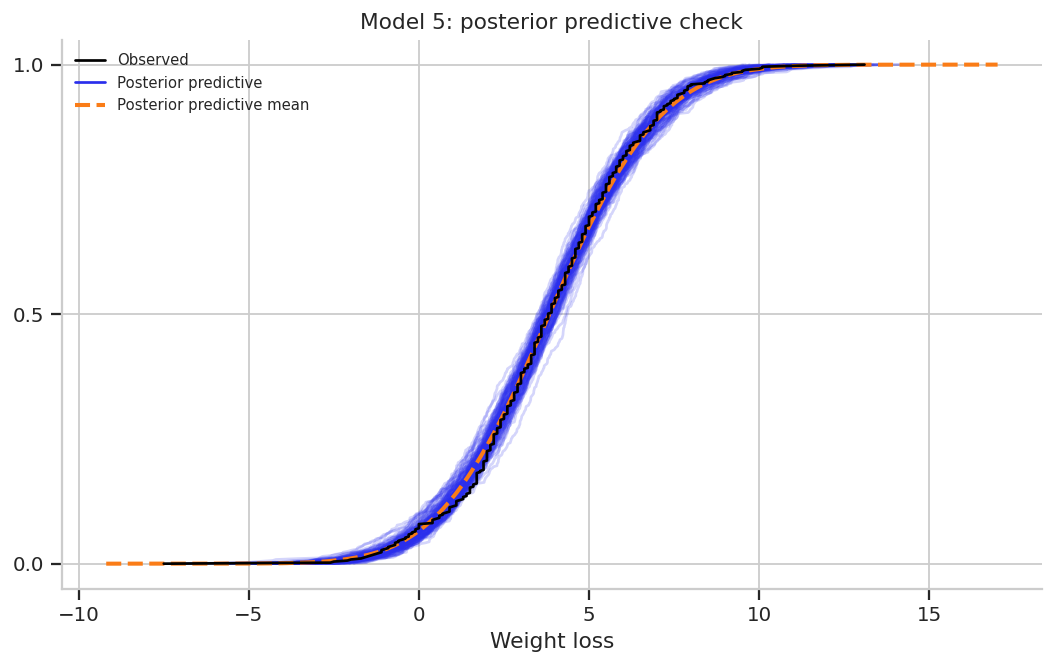

In [47]:
height_age_diet_model.predict(
    idata_height_age_diet,
    kind="pps",
    inplace=True,
    random_seed=RANDOM_SEED,
)

az.plot_ppc(
    idata_height_age_diet,
    group="posterior",
    observed=True,
    kind="cumulative",
    num_pp_samples=100,
)

plt.title("Model 5: posterior predictive check")
plt.xlabel("Weight loss")
plt.show()


### Model 5 — Interpretation notes

This is the most complex candidate model in the tutorial.

It can improve predictive performance if diet type contains information not already captured by height, age, and their interaction. If the predictive improvement is small relative to uncertainty, a simpler model may be preferable.


# Part C — Model comparison

We now compare the candidate models.

Important:

- Only compare models after checking diagnostics and posterior predictive checks.
- WAIC and LOO compare expected predictive accuracy, not scientific truth.
- Predictive ranking does not replace interpretation.
- Small differences relative to their uncertainty should not be over-interpreted.

## 13. Collect fitted Bayesian models

We collect the fitted `InferenceData` objects in a dictionary only after all models have been fit and checked.

In [48]:
bayesian_idatas = {
    "intercept only": idata_intercept,
    "height only": idata_height,
    "height + age": idata_height_age,
    "height * age": idata_height_age_interaction,
    "height * age + diet": idata_height_age_diet,
}

for model_name, idata in bayesian_idatas.items():
    print(model_name, "groups:", idata.groups())
    if "log_likelihood" not in idata.groups():
        print("  WARNING: log_likelihood group is missing.")


intercept only groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']
height only groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']
height + age groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']
height * age groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']
height * age + diet groups: ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data']


## 14. AIC

AIC is a frequentist information criterion.

It uses:
- a point estimate of model fit through the likelihood
- a penalty based on the number of parameters

Lower AIC means better estimated predictive performance on the AIC scale.

AIC is included here because it appears in the lecture, but our main Bayesian comparison will use WAIC and LOO.

In [49]:
ols_models = {
    model_name: smf.ols(formula, data=food).fit()
    for model_name, formula in candidate_formulas.items()
}

aic_table = pd.DataFrame({
    "model": list(ols_models.keys()),
    "formula": [candidate_formulas[name] for name in ols_models.keys()],
    "AIC": [fit.aic for fit in ols_models.values()],
    "n_parameters": [int(fit.df_model + 1) for fit in ols_models.values()],
}).sort_values("AIC")

aic_table["delta_AIC"] = aic_table["AIC"] - aic_table["AIC"].min()

display(aic_table.round(3))

,model,formula,AIC,n_parameters,delta_AIC
4,height * age + diet,weight_loss ~ height_z * age_z + diet_type,2203.889,6,0.000
3,height * age,weight_loss ~ height_z * age_z,2250.923,4,47.034
1,height only,weight_loss ~ height_z,2251.680,2,47.791
2,height + age,weight_loss ~ height_z + age_z,2253.680,3,49.791
0,intercept only,weight_loss ~ 1,2255.032,1,51.143


### Interpreting the AIC table

- Lower AIC is better.
- `delta_AIC` is the difference from the best-ranked model.
- The absolute AIC value is usually less meaningful than differences between models.
- AIC is not posterior-based. It is not the same as WAIC or LOO.

## 15. WAIC

WAIC is a Bayesian information criterion.

It uses the full posterior distribution and the pointwise log likelihood.

ArviZ reports WAIC using expected log predictive density (`elpd_waic`) by default.

With the default log scale:

- higher `elpd_waic` is better
- `elpd_diff` is the difference from the best-ranked model
- `p_waic` estimates the effective number of parameters
- `warning=True` means the estimate may be unreliable

In [50]:
waic_comparison = az.compare(
    bayesian_idatas,
    ic="waic",
)

display(waic_comparison)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
height * age + diet,0,-1103.702018,8.316358,0.000000,8.966781e-01,19.669305,0.000000,True,log
height only,1,-1127.073841,3.406008,23.371823,1.033219e-01,18.658446,7.512974,True,log
height * age,2,-1127.094728,6.144038,23.392710,3.538487e-15,18.803357,7.105730,True,log
height + age,3,-1128.274888,4.803265,24.572869,6.842673e-16,18.700813,7.531741,True,log
intercept only,4,-1128.754398,2.407639,25.052380,0.000000e+00,18.318632,7.614967,True,log


### Interpreting WAIC

Use WAIC to estimate predictive performance, but do not treat the rank as a final scientific conclusion.

Check:

1. Which model has rank 0?
2. Are the `elpd_diff` values large relative to `dse`?
3. Are there warnings?
4. Is the more complex model worth the added complexity?

## 16. PSIS-LOO

LOO estimates leave-one-out cross-validation.

In exact leave-one-out cross-validation, each observation is left out once, the model is refit, and the left-out observation is predicted.

PSIS-LOO approximates this without refitting the model \(N\) times.

This is usually the main Bayesian predictive comparison tool in this tutorial.

With the default log scale:

- higher `elpd_loo` is better
- `p_loo` estimates effective complexity
- `elpd_diff` is the difference from the best-ranked model
- `dse` is the standard error of the difference
- `warning=True` means the PSIS approximation should be checked

In [51]:
loo_comparison = az.compare(
    bayesian_idatas,
    ic="loo",
)

display(loo_comparison)

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
height * age + diet,0,-1103.721804,8.336143,0.000000,8.964755e-01,19.669590,0.000000,False,log
height only,1,-1127.080533,3.412700,23.358729,1.035245e-01,18.659916,7.513641,False,log
height * age,2,-1127.101450,6.150760,23.379646,4.054736e-15,18.802655,7.104992,False,log
height + age,3,-1128.282123,4.810501,24.560319,1.368550e-15,18.700759,7.532294,False,log
intercept only,4,-1128.757168,2.410409,25.035364,0.000000e+00,18.318944,7.615476,False,log


### Interpreting LOO

A useful interpretation template:

> The best-ranked model according to PSIS-LOO is ______.  
> The difference between this model and ______ is ______.  
> Compared with the standard error of the difference (`dse`), this difference is small / moderate / large.  
> Therefore, the predictive advantage is weak / uncertain / meaningful.

Do not say that a model is "true" because it has the best LOO score.

## 17. Compare WAIC and LOO rankings

WAIC and LOO often give similar results, but LOO is usually preferred when the PSIS diagnostics are reliable.

In [52]:
comparison_side_by_side = pd.DataFrame({
    "WAIC_rank": waic_comparison["rank"],
    "WAIC_elpd": waic_comparison["elpd_waic"],
    "WAIC_elpd_diff": waic_comparison["elpd_diff"],
    "LOO_rank": loo_comparison["rank"],
    "LOO_elpd": loo_comparison["elpd_loo"],
    "LOO_elpd_diff": loo_comparison["elpd_diff"],
})

display(comparison_side_by_side.round(3))

,WAIC_rank,WAIC_elpd,WAIC_elpd_diff,LOO_rank,LOO_elpd,LOO_elpd_diff
height * age + diet,0,-1103.702,0.000,0,-1103.722,0.000
height only,1,-1127.074,23.372,1,-1127.081,23.359
height * age,2,-1127.095,23.393,2,-1127.101,23.380
height + age,3,-1128.275,24.573,3,-1128.282,24.560
intercept only,4,-1128.754,25.052,4,-1128.757,25.035


# Part D — Pareto \(k\) diagnostics

This section is optional if time is short.

Pareto \(k\) is a diagnostic for the reliability of the PSIS-LOO approximation.

Large Pareto \(k\) values suggest that one or more observations are highly influential, so the LOO estimate may be unreliable.

The key idea:

> Pareto \(k\) checks the approximation used by PSIS-LOO. It is not a general measure of whether the model is scientifically correct.

## 18. LOO diagnostics for each model

In [53]:
loo_results = {}

for model_name, idata in bayesian_idatas.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    loo_result = az.loo(
        idata,
        pointwise=True,
        scale="log",
    )
    loo_results[model_name] = loo_result
    print(loo_result)

intercept only
Computed from 4000 posterior samples and 480 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1128.76    18.32
p_loo        2.41        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      480  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

height only
Computed from 4000 posterior samples and 480 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1127.08    18.66
p_loo        3.41        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      480  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

height + age
Computed from 4000 posterior samples and 480 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1128.28    18.70
p_loo        4.81        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   

## 19. Pareto \(k\) plot for the best LOO model

The following code identifies the best-ranked LOO model and plots its Pareto \(k\) values.

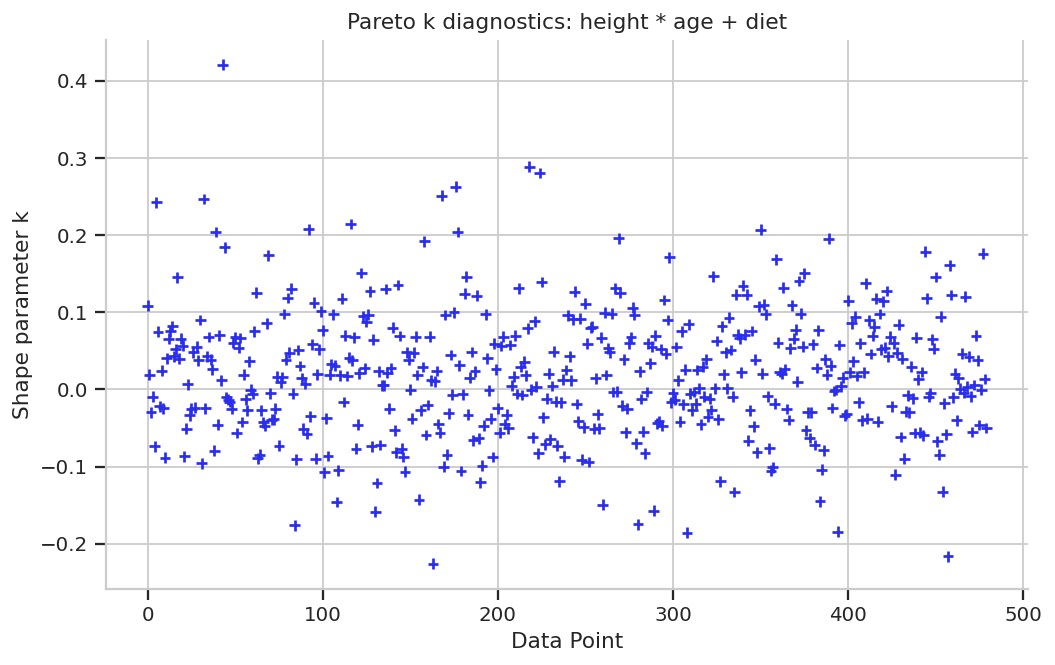

In [54]:
best_loo_model_name = loo_comparison.index[0]
best_loo_result = loo_results[best_loo_model_name]

az.plot_khat(best_loo_result)
plt.title(f"Pareto k diagnostics: {best_loo_model_name}")
plt.show()

### Pareto \(k\) interpretation notes

Pareto \(k\) tells us whether the PSIS-LOO approximation is reliable for each observation.

- Low Pareto \(k\) values suggest that the PSIS-LOO approximation is reliable.
- High Pareto \(k\) values suggest influential observations.
- If there are problematic values, the LOO comparison should be interpreted cautiously.
- In serious analyses, problematic cases may require refitting, exact cross-validation, or model revision.

# Part E — Effect-size summaries

Predictive comparison and effect-size summaries answer different questions.

- AIC, WAIC, and LOO ask: **Which model is expected to predict new data better?**
- \(R^2\), partial \(R^2\), \(\eta^2\), and Cohen's \(f\) ask: **How large are the model or term contributions?**

This section summarizes the effect-size measures learned in the previous tutorial using the matching OLS models.

In [55]:
def model_level_effect_sizes(result, model_name, formula):
    r2 = result.rsquared
    cohens_f_model = np.sqrt(r2 / (1 - r2)) if r2 < 1 else np.inf
    return {
        "model": model_name,
        "formula": formula,
        "R2": r2,
        "cohens_f_model": cohens_f_model,
        "df_model": result.df_model,
        "df_resid": result.df_resid,
    }


model_effect_size_table = pd.DataFrame([
    model_level_effect_sizes(
        result=ols_models[model_name],
        model_name=model_name,
        formula=candidate_formulas[model_name],
    )
    for model_name in candidate_formulas
])

display(model_effect_size_table.round(4))

,model,formula,R2,cohens_f_model,df_model,df_resid
0,intercept only,weight_loss ~ 1,0.0000,0.0000,0.0,479.0
1,height only,weight_loss ~ height_z,0.0111,0.1059,1.0,478.0
2,height + age,weight_loss ~ height_z + age_z,0.0111,0.1059,2.0,477.0
3,height * age,weight_loss ~ height_z * age_z,0.0208,0.1459,3.0,476.0
4,height * age + diet,weight_loss ~ height_z * age_z + diet_type,0.1196,0.3686,5.0,474.0


## 20. Term-level effect-size table

For each model term, the table reports:

\[
\eta^2 = \frac{SS_{term}}{SS_{total}}
\]

\[
R^2_{partial,term} = \frac{SS_{term}}{SS_{term} + SS_{residual}}
\]

\[
f = \sqrt{\frac{SS_{term}}{SS_{residual}}}
\]

These effect sizes describe magnitude. They do not replace diagnostics, posterior predictive checks, or model comparison.

In [56]:
def anova_with_effect_sizes(result, model_name, typ=2):
    ss_total = np.sum((result.model.endog - np.mean(result.model.endog)) ** 2)
    ss_residual = result.ssr

    if result.df_model == 0:
        return pd.DataFrame([{
            "model": model_name,
            "term": "intercept only",
            "SS": np.nan,
            "df": result.df_model,
            "eta_sq": np.nan,
            "partial_R2_term": np.nan,
            "cohens_f": np.nan,
            "SS_residual": ss_residual,
            "SS_total": ss_total,
        }])

    table = anova_lm(result, typ=typ).copy()
    table = table.rename(columns={"sum_sq": "SS", "df": "df"})

    if "Residual" in table.index:
        table = table.drop(index="Residual")

    table["eta_sq"] = table["SS"] / ss_total
    table["partial_R2_term"] = table["SS"] / (table["SS"] + ss_residual)
    table["cohens_f"] = np.sqrt(table["SS"] / ss_residual)
    table["SS_residual"] = ss_residual
    table["SS_total"] = ss_total

    table.insert(0, "model", model_name)
    table.insert(1, "term", table.index)
    table = table.reset_index(drop=True)

    columns_to_keep = [
        "model", "term", "SS", "df", "eta_sq", "partial_R2_term",
        "cohens_f", "SS_residual", "SS_total"
    ]
    return table[columns_to_keep]


term_effect_size_table = pd.concat(
    [
        anova_with_effect_sizes(
            result=ols_models[model_name],
            model_name=model_name,
            typ=2,
        )
        for model_name in candidate_formulas
    ],
    ignore_index=True,
)

display(term_effect_size_table.round(4))

,model,term,SS,df,eta_sq,partial_R2_term,cohens_f,SS_residual,SS_total
0,intercept only,intercept only,NaN,0.0,NaN,NaN,NaN,3070.8998,3070.8998
1,height only,height_z,34.0479,1.0,0.0111,0.0111,0.1059,3036.8519,3070.8998
2,height + age,height_z,33.8551,1.0,0.0110,0.0110,0.1056,3036.8499,3070.8998
3,height + age,age_z,0.0020,1.0,0.0000,0.0000,0.0008,3036.8499,3070.8998
4,height * age,height_z,33.8551,1.0,0.0110,0.0111,0.1061,3006.9001,3070.8998
5,height * age,age_z,0.0020,1.0,0.0000,0.0000,0.0008,3006.9001,3070.8998
6,height * age,height_z:age_z,29.9498,1.0,0.0098,0.0099,0.0998,3006.9001,3070.8998
7,height * age + diet,diet_type,303.2868,2.0,0.0988,0.1009,0.3349,2703.6133,3070.8998
8,height * age + diet,height_z,2.6410,1.0,0.0009,0.0010,0.0313,2703.6133,3070.8998
9,height * age + diet,age_z,2.4275,1.0,0.0008,0.0009,0.0300,2703.6133,3070.8998


## 21. Final synthesis

Use the model comparison results together with diagnostics, posterior predictive checks, effect-size summaries, and scientific interpretation.

A complete conclusion should include:

1. Which model ranked best by LOO?
2. Were the differences large relative to uncertainty?
3. Did any model have warnings?
4. Does the added complexity have a clear predictive benefit?
5. What do the effect-size summaries say about the magnitude of the model terms?
6. Does the model answer the scientific question in an interpretable way?

## Suggested conclusion template

> The best-ranked model according to PSIS-LOO was ______.  
> However, its predictive advantage over ______ was small / moderate / large relative to `dse`.  
> The posterior predictive checks were acceptable / problematic.  
> The effect-size summary suggests that ______ has a small / moderate / large contribution.  
> Therefore, we would choose ______ because it balances predictive performance, reliability, magnitude, and interpretability.

## Take-home messages

1. Model comparison estimates expected predictive performance on new data.
2. Explained-variance summaries and predictive comparison answer different questions.
3. WAIC and LOO require pointwise log likelihood.
4. LOO is usually the main Bayesian predictive comparison tool.
5. Check diagnostics before comparing models.
6. Check posterior predictive performance before trusting a predictive ranking.
7. Pareto \(k\) is a diagnostic for the PSIS-LOO approximation.
8. Effect-size summaries describe magnitude, not predictive ranking.
9. The best predictive model is not automatically the best scientific model.

## 22. Watermark

In [57]:
%load_ext watermark
%watermark -v -p numpy,pandas,matplotlib,seaborn,scipy,pymc,arviz,bambi,preliz,statsmodels

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 7.34.0

numpy      : 2.0.2
pandas     : 2.2.2
matplotlib : 3.10.0
seaborn    : 0.13.2
scipy      : 1.16.3
pymc       : 5.28.4
arviz      : 0.22.0
bambi      : 0.17.2
preliz     : 0.24.0
statsmodels: 0.14.6

